In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = datasets.FashionMNIST(root="data", train=True,  download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)


## Baseline model: SmallCNN

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.fc1   = nn.Linear(32*7*7, 128)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))  
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SmallCNN().to(device)
print(model)


SmallCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = total_correct = total_samples = 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss   += loss.item() * x.size(0)
        preds         = logits.argmax(1)
        total_correct += (preds==y).sum().item()
        total_samples += y.size(0)

    return total_loss/total_samples, total_correct/total_samples

def eval_model(model, loader, criterion):
    model.eval()
    total_loss = total_correct = 0
    ys, ps = [], []
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)
            total_loss   += loss.item() * x.size(0)
            preds         = logits.argmax(1)
            total_correct += (preds==y).sum().item()

            ys.append(y.cpu())
            ps.append(preds.cpu())
    ys = torch.cat(ys).numpy()
    ps = torch.cat(ps).numpy()
    f1 = f1_score(ys, ps, average='weighted')
    return total_loss/len(loader.dataset), total_correct/len(loader.dataset), f1

def get_model_size_mb(model):
    torch.save(model.state_dict(), "tmp.pth")
    size = os.path.getsize("tmp.pth")/1e6
    os.remove("tmp.pth")
    return size

def measure_inference_time(model, loader, runs=100):
    model.eval()
    # warm-up
    for x,_ in loader:
        _ = model(x.to(device))
        break
    times = []
    with torch.no_grad():
        for _ in range(runs):
            for x,_ in loader:
                start = time.time()
                _ = model(x.to(device))
                times.append(time.time()-start)
                break
    return (sum(times)/len(times)) * 1000


In [ ]:
# One-shot training & eval on baseline
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 15

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

for epoch in range(1, num_epochs+1):
    tr_l, tr_a = train_epoch(model, train_loader, optimizer, criterion)
    vl, va, vf = eval_model(model, test_loader, criterion)
    history['train_loss'].append(tr_l)
    history['train_acc'].append(tr_a)
    history['val_loss'].append(vl)
    history['val_acc'].append(va)
    history['val_f1'].append(vf)
    print(f"Epoch {epoch}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")


Epoch 1: train_acc=0.8296, val_acc=0.8750, val_f1=0.8710
Epoch 2: train_acc=0.8900, val_acc=0.8851, val_f1=0.8861
Epoch 3: train_acc=0.9060, val_acc=0.9032, val_f1=0.9029
Epoch 4: train_acc=0.9160, val_acc=0.9064, val_f1=0.9064
Epoch 5: train_acc=0.9244, val_acc=0.9033, val_f1=0.9042
Epoch 6: train_acc=0.9311, val_acc=0.9159, val_f1=0.9149
Epoch 7: train_acc=0.9388, val_acc=0.9141, val_f1=0.9142
Epoch 8: train_acc=0.9423, val_acc=0.9085, val_f1=0.9081
Epoch 9: train_acc=0.9491, val_acc=0.9187, val_f1=0.9180
Epoch 10: train_acc=0.9546, val_acc=0.9185, val_f1=0.9177
Epoch 11: train_acc=0.9589, val_acc=0.9158, val_f1=0.9165
Epoch 12: train_acc=0.9635, val_acc=0.9145, val_f1=0.9137
Epoch 13: train_acc=0.9679, val_acc=0.9181, val_f1=0.9179
Epoch 14: train_acc=0.9708, val_acc=0.9204, val_f1=0.9207
Epoch 15: train_acc=0.9738, val_acc=0.9166, val_f1=0.9164


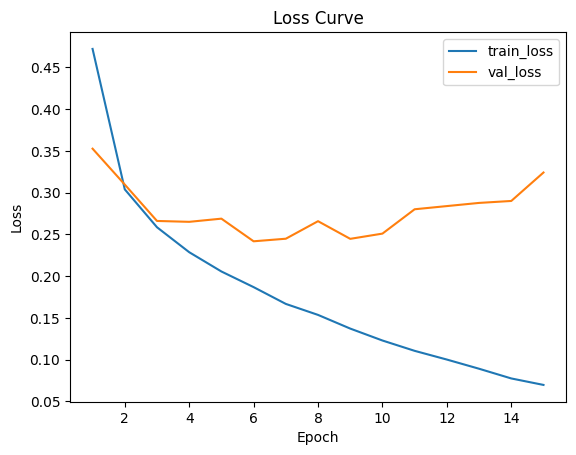

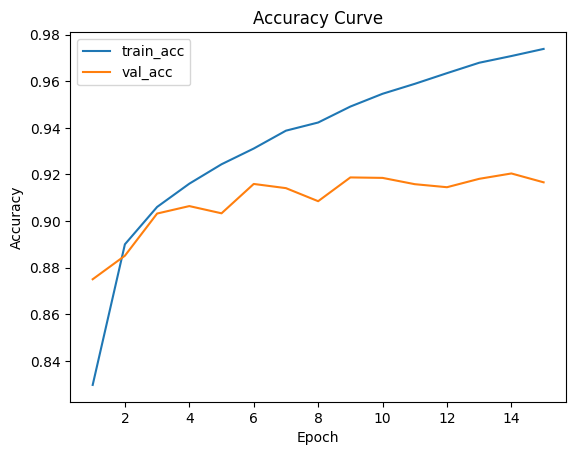

In [ ]:
epochs = range(1, num_epochs+1)
plt.figure(); plt.plot(epochs, history['train_loss'], label='train_loss'); plt.plot(epochs, history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curve'); plt.show()

plt.figure(); plt.plot(epochs, history['train_acc'], label='train_acc'); plt.plot(epochs, history['val_acc'], label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy Curve'); plt.show()


In [ ]:
size_mb = get_model_size_mb(model)
inf_ms  = measure_inference_time(model, test_loader)
print(f"Baseline SmallCNN → size: {size_mb:.2f} MB, inference: {inf_ms:.2f} ms/batch")
print(f"Design contributions:\n"
      f" • Accuracy: val_acc={history['val_acc'][-1]:.4f}, val_f1={history['val_f1'][-1]:.4f}\n"
      f" • Time: train_epochs={num_epochs}, inference={inf_ms:.1f} ms\n"
      f" • Memory: model_size={size_mb:.1f} MB\n"
      f" • Power/Energy & Privacy/Security: minimal compute, no external data\n")


Baseline SmallCNN → size: 0.83 MB, inference: 0.54 ms/batch
Design contributions:
 • Accuracy: val_acc=0.9166, val_f1=0.9164
 • Time: train_epochs=15, inference=0.5 ms
 • Memory: model_size=0.8 MB
 • Power/Energy & Privacy/Security: minimal compute, no external data



In [ ]:
from itertools import product
import pandas as pd

search_space = {
    'lr': [1e-4, 5e-4, 1e-3],
    'batch_size': [32, 64, 128]
}

results = []
best_acc = 0.0
best_cfg = None

for lr, bs in product(search_space['lr'], search_space['batch_size']):
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    m = SmallCNN().to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    for _ in range(10): train_epoch(m, train_loader, opt, criterion)
    _, acc, f1 = eval_model(m, test_loader, criterion)
    results.append({'lr':lr,'batch_size':bs,'acc':acc,'f1':f1})
    if acc > best_acc:
        best_acc = acc; best_cfg = (lr,bs)

df = pd.DataFrame(results)
print("Best cfg:", best_cfg, "→ acc:", best_acc)


Best cfg: (0.001, 32) → acc: 0.9151


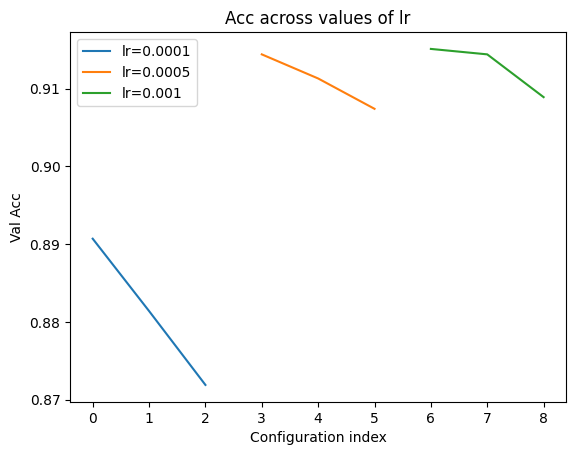

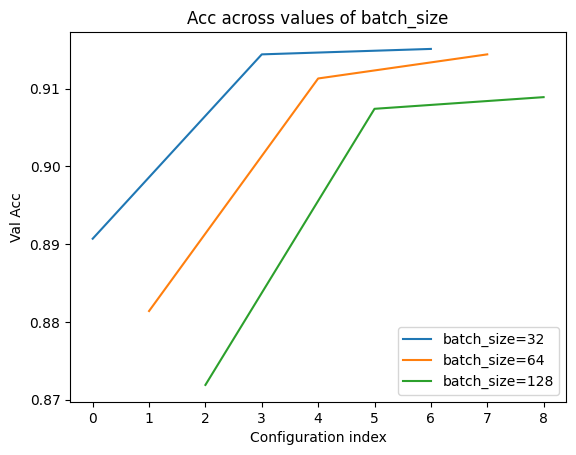

In [ ]:
for param in ['lr','batch_size']:
    plt.figure()
    for val in df[param].unique():
        sub = df[df[param]==val]
        plt.plot(sub['acc'], label=f"{param}={val}")
    plt.title(f"Acc across values of {param}")
    plt.xlabel('Configuration index'); plt.ylabel('Val Acc'); plt.legend(); plt.show()


In [ ]:
best_lr, best_bs = best_cfg
print(f"Retraining SmallCNN with lr={best_lr}, batch_size={best_bs}")
train_loader = DataLoader(train_ds, batch_size=best_bs, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=best_bs, shuffle=False)
model_opt   = SmallCNN().to(device)
optimizer_opt = optim.Adam(model_opt.parameters(), lr=best_lr)

history_opt = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
start_time = time.time()
for epoch in range(1, num_epochs+1):
    tr_l, tr_a   = train_epoch(model_opt, train_loader, optimizer_opt, criterion)
    vl, va, vf   = eval_model(model_opt, test_loader, criterion)
    history_opt['train_loss'].append(tr_l)
    history_opt['train_acc'].append(tr_a)
    history_opt['val_loss'].append(vl)
    history_opt['val_acc'].append(va)
    history_opt['val_f1'].append(vf)
    print(f"[Opt] Epoch {epoch}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")
train_time_opt = time.time() - start_time


Retraining SmallCNN with lr=0.001, batch_size=32
[Opt] Epoch 1: train_acc=0.8461, val_acc=0.8785, val_f1=0.8780
[Opt] Epoch 2: train_acc=0.8968, val_acc=0.9015, val_f1=0.9021
[Opt] Epoch 3: train_acc=0.9126, val_acc=0.9082, val_f1=0.9085
[Opt] Epoch 4: train_acc=0.9246, val_acc=0.9119, val_f1=0.9123
[Opt] Epoch 5: train_acc=0.9327, val_acc=0.9156, val_f1=0.9157
[Opt] Epoch 6: train_acc=0.9417, val_acc=0.9174, val_f1=0.9167
[Opt] Epoch 7: train_acc=0.9483, val_acc=0.9171, val_f1=0.9161
[Opt] Epoch 8: train_acc=0.9540, val_acc=0.9192, val_f1=0.9194
[Opt] Epoch 9: train_acc=0.9590, val_acc=0.9174, val_f1=0.9170
[Opt] Epoch 10: train_acc=0.9653, val_acc=0.9188, val_f1=0.9192
[Opt] Epoch 11: train_acc=0.9688, val_acc=0.9129, val_f1=0.9124
[Opt] Epoch 12: train_acc=0.9735, val_acc=0.9161, val_f1=0.9162
[Opt] Epoch 13: train_acc=0.9766, val_acc=0.9161, val_f1=0.9165
[Opt] Epoch 14: train_acc=0.9781, val_acc=0.9177, val_f1=0.9174
[Opt] Epoch 15: train_acc=0.9810, val_acc=0.9178, val_f1=0.9182


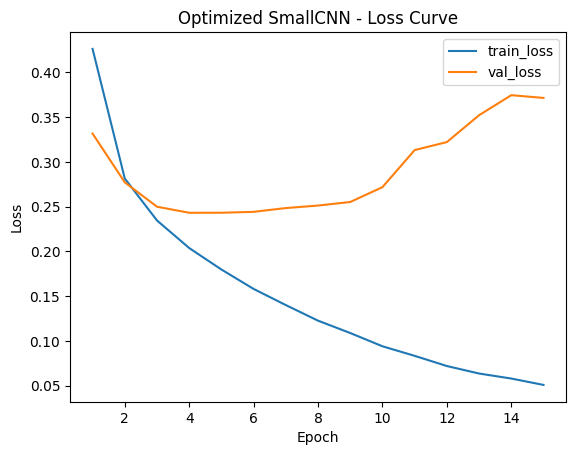

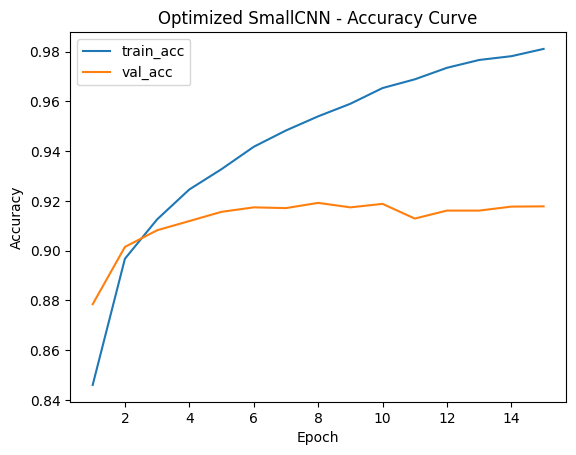

In [ ]:
epochs = range(1, num_epochs+1)

plt.figure()
plt.plot(epochs, history_opt['train_loss'], label='train_loss')
plt.plot(epochs, history_opt['val_loss'],   label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Optimized SmallCNN - Loss Curve')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, history_opt['train_acc'], label='train_acc')
plt.plot(epochs, history_opt['val_acc'],   label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Optimized SmallCNN - Accuracy Curve')
plt.legend()
plt.show()


In [ ]:
size_opt = get_model_size_mb(model_opt)
inf_opt  = measure_inference_time(model_opt, test_loader)

print("=== Optimized SmallCNN Metrics ===")
print(f"Val Acc: {history_opt['val_acc'][-1]:.4f}, Val F1: {history_opt['val_f1'][-1]:.4f}")
print(f"Model Size: {size_opt:.2f} MB")
print(f"Inference Time: {inf_opt:.2f} ms/batch")
print(f"Total Train Time: {train_time_opt:.1f} s")
print("Design contributions:")
print(f" • Accuracy: improved to {history_opt['val_acc'][-1]:.4f}")
print(f" • Time: train_time={train_time_opt:.1f}s, inference={inf_opt:.1f}ms")
print(f" • Memory: size={size_opt:.1f} MB")
print(f" • Power/Energy & Privacy/Security: same minimal compute, no external data")


=== Optimized SmallCNN Metrics ===
Val Acc: 0.9178, Val F1: 0.9182
Model Size: 0.83 MB
Inference Time: 0.50 ms/batch
Total Train Time: 232.5 s
Design contributions:
 • Accuracy: improved to 0.9178
 • Time: train_time=232.5s, inference=0.5ms
 • Memory: size=0.8 MB
 • Power/Energy & Privacy/Security: same minimal compute, no external data


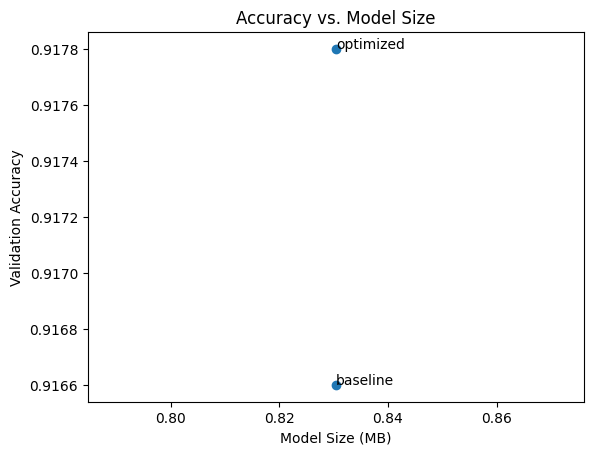

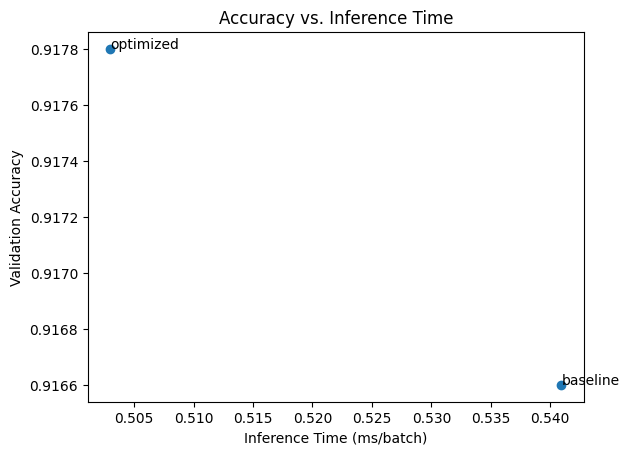

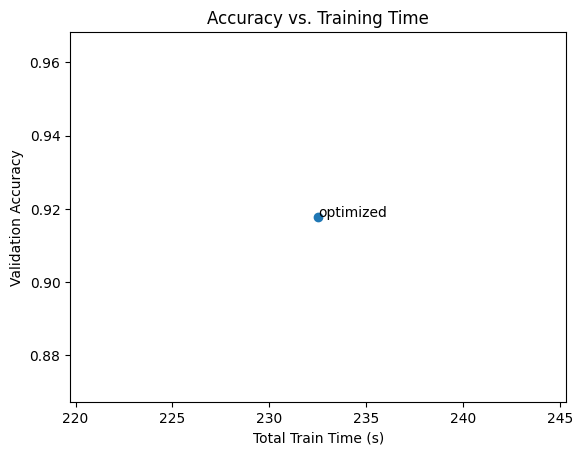

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame([
    {'model':'baseline',  'acc':history['val_acc'][-1], 'f1':history['val_f1'][-1],
     'size_mb': size_mb,            'inf_ms': inf_ms,             'train_s': None},
    {'model':'optimized', 'acc':history_opt['val_acc'][-1], 'f1':history_opt['val_f1'][-1],
     'size_mb': size_opt,           'inf_ms': inf_opt,            'train_s': train_time_opt},
])

# Accuracy vs Model Size
plt.figure()
plt.scatter(metrics_df['size_mb'], metrics_df['acc'])
for _, r in metrics_df.iterrows():
    plt.text(r['size_mb'], r['acc'], r['model'])
plt.xlabel('Model Size (MB)')
plt.ylabel('Validation Accuracy')
plt.title('Accuracy vs. Model Size')
plt.show()

# Accuracy vs Inference Time
plt.figure()
plt.scatter(metrics_df['inf_ms'], metrics_df['acc'])
for _, r in metrics_df.iterrows():
    plt.text(r['inf_ms'], r['acc'], r['model'])
plt.xlabel('Inference Time (ms/batch)')
plt.ylabel('Validation Accuracy')
plt.title('Accuracy vs. Inference Time')
plt.show()

# Accuracy vs Train Time
plt.figure()
# skip baseline since train_s=None
opt = metrics_df.dropna(subset=['train_s'])
plt.scatter(opt['train_s'], opt['acc'])
for _, r in opt.iterrows():
    plt.text(r['train_s'], r['acc'], r['model'])
plt.xlabel('Total Train Time (s)')
plt.ylabel('Validation Accuracy')
plt.title('Accuracy vs. Training Time')
plt.show()


In [ ]:
class TargetCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # → 28×28×32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # → 14×14×64
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # → 7×7×128
        self.pool  = nn.MaxPool2d(2,2)
        self.fc1   = nn.Linear(128*3*3, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)                       # 28→14
        x = F.relu(self.conv2(x))
        x = self.pool(x)                       # 14→7
        x = F.relu(self.conv3(x))
        x = self.pool(x)                       # 7→3
        x = x.view(x.size(0), -1)              # flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# instantiate
target_model = TargetCNN().to(device)
print(target_model)


TargetCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [23]:
# 2) One-shot training & evaluation for TargetCNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(target_model.parameters(), lr=1e-3)
num_epochs = 15

history_t = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

for ep in range(1, num_epochs+1):
    tr_l, tr_a = train_epoch(target_model, train_loader, optimizer, criterion)
    vl, va, vf = eval_model(target_model, test_loader, criterion)
    history_t['train_loss'].append(tr_l)
    history_t['train_acc'].append(tr_a)
    history_t['val_loss'].append(vl)
    history_t['val_acc'].append(va)
    history_t['val_f1'].append(vf)
    print(f"TargetCNN Epoch {ep}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")


TargetCNN Epoch 1: train_acc=0.8456, val_acc=0.8826, val_f1=0.8810
TargetCNN Epoch 2: train_acc=0.9022, val_acc=0.9077, val_f1=0.9065
TargetCNN Epoch 3: train_acc=0.9188, val_acc=0.9110, val_f1=0.9113
TargetCNN Epoch 4: train_acc=0.9290, val_acc=0.9022, val_f1=0.9033
TargetCNN Epoch 5: train_acc=0.9380, val_acc=0.9157, val_f1=0.9150
TargetCNN Epoch 6: train_acc=0.9467, val_acc=0.9205, val_f1=0.9207
TargetCNN Epoch 7: train_acc=0.9525, val_acc=0.9190, val_f1=0.9188
TargetCNN Epoch 8: train_acc=0.9606, val_acc=0.9209, val_f1=0.9199
TargetCNN Epoch 9: train_acc=0.9647, val_acc=0.9245, val_f1=0.9243
TargetCNN Epoch 10: train_acc=0.9707, val_acc=0.9175, val_f1=0.9181
TargetCNN Epoch 11: train_acc=0.9731, val_acc=0.9116, val_f1=0.9120
TargetCNN Epoch 12: train_acc=0.9754, val_acc=0.9156, val_f1=0.9157
TargetCNN Epoch 13: train_acc=0.9783, val_acc=0.9181, val_f1=0.9176
TargetCNN Epoch 14: train_acc=0.9806, val_acc=0.9153, val_f1=0.9156
TargetCNN Epoch 15: train_acc=0.9813, val_acc=0.9165, val

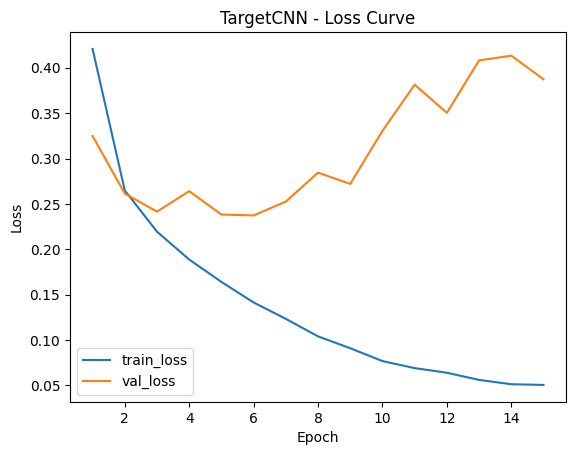

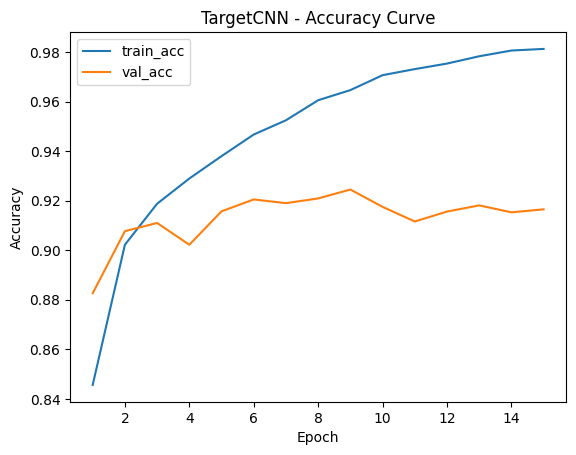

In [24]:
# 3) Plot train/val curves for TargetCNN
epochs = range(1, num_epochs+1)

plt.figure()
plt.plot(epochs, history_t['train_loss'], label='train_loss')
plt.plot(epochs, history_t['val_loss'],   label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('TargetCNN - Loss Curve')
plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history_t['train_acc'], label='train_acc')
plt.plot(epochs, history_t['val_acc'],   label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('TargetCNN - Accuracy Curve')
plt.legend(); plt.show()


In [25]:
# 4) Baseline metrics summary for TargetCNN
size_t   = get_model_size_mb(target_model)
inf_t    = measure_inference_time(target_model, test_loader)

print("=== TargetCNN Initial Metrics ===")
print(f"Val Acc: {history_t['val_acc'][-1]:.4f}, Val F1: {history_t['val_f1'][-1]:.4f}")
print(f"Model Size: {size_t:.2f} MB")
print(f"Inference Time: {inf_t:.2f} ms/batch")
print("Design contributions:")
print(f" • Accuracy: val_acc={history_t['val_acc'][-1]:.4f}")
print(f" • Time: inference={inf_t:.1f}ms")
print(f" • Memory: size={size_t:.1f} MB")
print(f" • Power/Energy & Privacy/Security: moderate compute, no external data")


=== TargetCNN Initial Metrics ===
Val Acc: 0.9165, Val F1: 0.9167
Model Size: 1.56 MB
Inference Time: 0.54 ms/batch
Design contributions:
 • Accuracy: val_acc=0.9165
 • Time: inference=0.5ms
 • Memory: size=1.6 MB
 • Power/Energy & Privacy/Security: moderate compute, no external data


In [26]:
# 5) Hyperparameter search for TargetCNN (lr & batch_size)
results_t = []
best_acc_t = 0.0
best_cfg_t = None

for lr, bs in product(search_space['lr'], search_space['batch_size']):
    # reload model/data
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    m = TargetCNN().to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    # quick 3-epoch runs
    for _ in range(5): train_epoch(m, train_loader, opt, criterion)
    _, acc, f1 = eval_model(m, test_loader, criterion)
    results_t.append({'lr':lr,'batch_size':bs,'acc':acc,'f1':f1})
    if acc > best_acc_t:
        best_acc_t = acc
        best_cfg_t = (lr,bs)

df_t = pd.DataFrame(results_t)
print("TargetCNN Best cfg:", best_cfg_t, "→ acc:", best_acc_t)


TargetCNN Best cfg: (0.001, 128) → acc: 0.9151


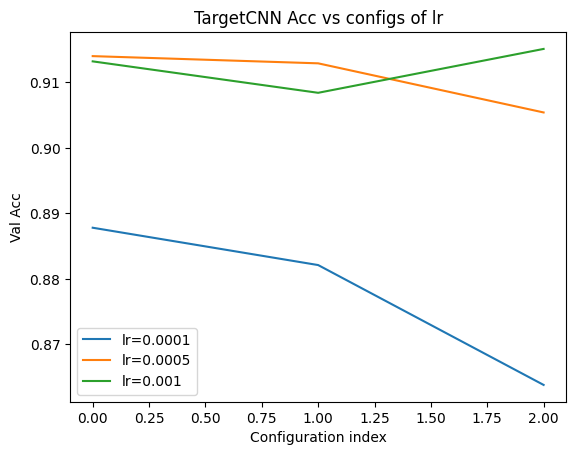

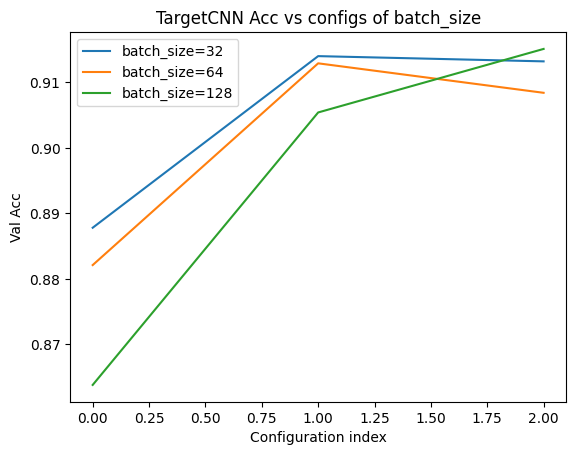

In [27]:
# 6) Visualize HP effects for TargetCNN
for param in ['lr','batch_size']:
    plt.figure()
    for val in df_t[param].unique():
        sub = df_t[df_t[param]==val]
        plt.plot(sub['acc'].values, label=f"{param}={val}")
    plt.title(f"TargetCNN Acc vs configs of {param}")
    plt.xlabel('Configuration index'); plt.ylabel('Val Acc'); plt.legend(); plt.show()


In [28]:
# 7) Retrain TargetCNN with best hyperparameters
best_lr_t, best_bs_t = best_cfg_t
print(f"Retraining TargetCNN with lr={best_lr_t}, batch_size={best_bs_t}")

train_loader = DataLoader(train_ds, batch_size=best_bs_t, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=best_bs_t, shuffle=False)
model_opt_t   = TargetCNN().to(device)
optimizer_opt = optim.Adam(model_opt_t.parameters(), lr=best_lr_t)

history_opt_t = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
start = time.time()
for ep in range(1, num_epochs+1):
    tr_l, tr_a = train_epoch(model_opt_t, train_loader, optimizer_opt, criterion)
    vl, va, vf = eval_model(model_opt_t, test_loader, criterion)
    history_opt_t['train_loss'].append(tr_l)
    history_opt_t['train_acc'].append(tr_a)
    history_opt_t['val_loss'].append(vl)
    history_opt_t['val_acc'].append(va)
    history_opt_t['val_f1'].append(vf)
    print(f"[Opt-T] Epoch {ep}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")
train_time_opt_t = time.time() - start


Retraining TargetCNN with lr=0.001, batch_size=128
[Opt-T] Epoch 1: train_acc=0.8107, val_acc=0.8730, val_f1=0.8702
[Opt-T] Epoch 2: train_acc=0.8872, val_acc=0.8905, val_f1=0.8913
[Opt-T] Epoch 3: train_acc=0.9054, val_acc=0.9021, val_f1=0.9025
[Opt-T] Epoch 4: train_acc=0.9161, val_acc=0.9118, val_f1=0.9111
[Opt-T] Epoch 5: train_acc=0.9256, val_acc=0.9126, val_f1=0.9127
[Opt-T] Epoch 6: train_acc=0.9326, val_acc=0.9139, val_f1=0.9133
[Opt-T] Epoch 7: train_acc=0.9392, val_acc=0.9183, val_f1=0.9184
[Opt-T] Epoch 8: train_acc=0.9459, val_acc=0.9166, val_f1=0.9166
[Opt-T] Epoch 9: train_acc=0.9502, val_acc=0.9147, val_f1=0.9136
[Opt-T] Epoch 10: train_acc=0.9560, val_acc=0.9169, val_f1=0.9164
[Opt-T] Epoch 11: train_acc=0.9616, val_acc=0.9214, val_f1=0.9210
[Opt-T] Epoch 12: train_acc=0.9660, val_acc=0.9219, val_f1=0.9216
[Opt-T] Epoch 13: train_acc=0.9705, val_acc=0.9203, val_f1=0.9202
[Opt-T] Epoch 14: train_acc=0.9734, val_acc=0.9195, val_f1=0.9190
[Opt-T] Epoch 15: train_acc=0.9772

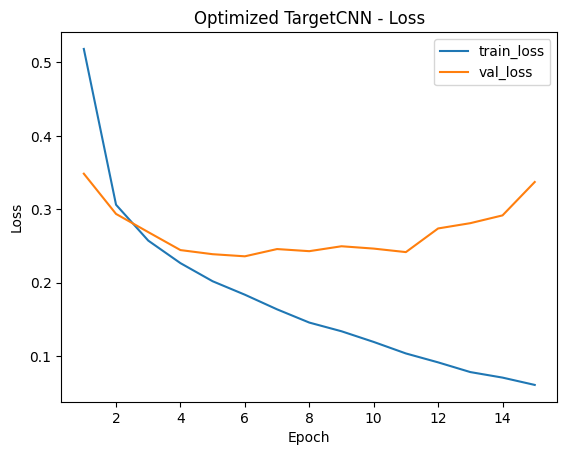

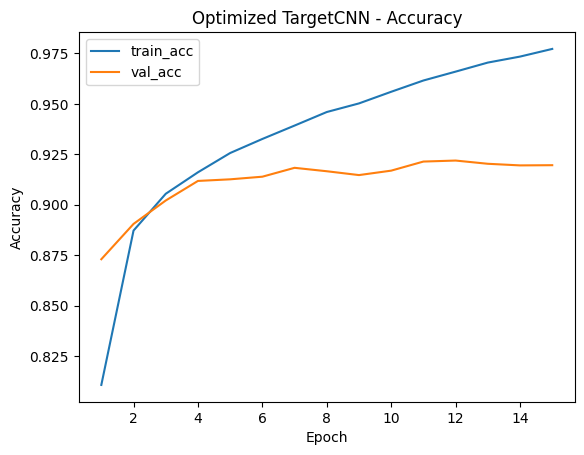

In [29]:
# 8) Plot optimized TargetCNN curves
plt.figure()
plt.plot(epochs, history_opt_t['train_loss'], label='train_loss')
plt.plot(epochs, history_opt_t['val_loss'],   label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Optimized TargetCNN - Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history_opt_t['train_acc'], label='train_acc')
plt.plot(epochs, history_opt_t['val_acc'],   label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Optimized TargetCNN - Accuracy'); plt.legend(); plt.show()


In [30]:
# 9) Optimized TargetCNN metrics
size_opt_t = get_model_size_mb(model_opt_t)
inf_opt_t  = measure_inference_time(model_opt_t, test_loader)

print("=== Optimized TargetCNN Metrics ===")
print(f"Val Acc: {history_opt_t['val_acc'][-1]:.4f}, Val F1: {history_opt_t['val_f1'][-1]:.4f}")
print(f"Model Size: {size_opt_t:.2f} MB, Inference: {inf_opt_t:.2f} ms/batch")
print(f"Train Time: {train_time_opt_t:.1f}s")


=== Optimized TargetCNN Metrics ===
Val Acc: 0.9196, Val F1: 0.9194
Model Size: 1.56 MB, Inference: 0.70 ms/batch
Train Time: 193.0s


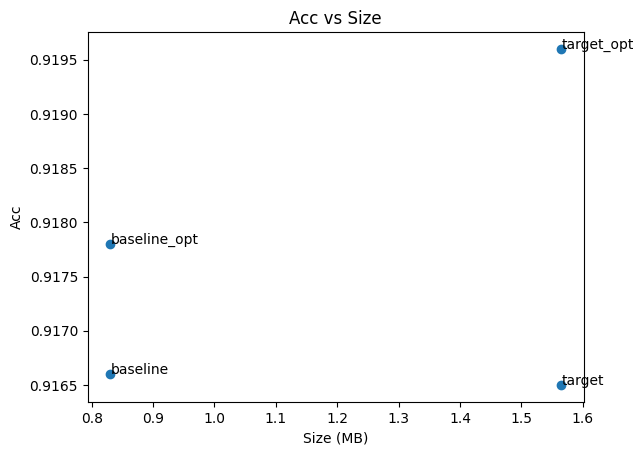

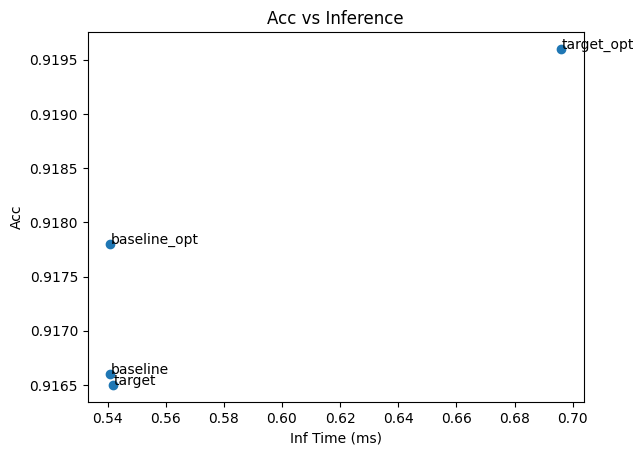

In [31]:
# 10) Trade-off comparison: baseline, optimized baseline, target, optimized target
metrics_all = pd.DataFrame([
    {'model':'baseline',     'acc':history['val_acc'][-1],      'size_mb':size_mb,    'inf_ms':inf_ms,       'train_s':None},
    {'model':'baseline_opt', 'acc':history_opt['val_acc'][-1], 'size_mb':size_mb,    'inf_ms':inf_ms,       'train_s':train_time_opt},
    {'model':'target',       'acc':history_t['val_acc'][-1],    'size_mb':size_t,     'inf_ms':inf_t,        'train_s':None},
    {'model':'target_opt',   'acc':history_opt_t['val_acc'][-1],'size_mb':size_opt_t, 'inf_ms':inf_opt_t,    'train_s':train_time_opt_t},
])

# Accuracy vs Model Size
plt.figure()
plt.scatter(metrics_all['size_mb'], metrics_all['acc'])
for _,r in metrics_all.iterrows(): plt.text(r['size_mb'], r['acc'], r['model'])
plt.xlabel('Size (MB)'); plt.ylabel('Acc'); plt.title('Acc vs Size'); plt.show()

# Accuracy vs Inference Time
plt.figure()
plt.scatter(metrics_all['inf_ms'], metrics_all['acc'])
for _,r in metrics_all.iterrows(): plt.text(r['inf_ms'], r['acc'], r['model'])
plt.xlabel('Inf Time (ms)'); plt.ylabel('Acc'); plt.title('Acc vs Inference'); plt.show()


In [32]:
# 1) ResNetEmbed class definition
from torchvision.models import resnet18

class ResNetEmbed(nn.Module):
    def __init__(self, num_classes=10, embedding_dim=64):
        super().__init__()
        # 1-channel ResNet-18 backbone
        self.backbone = resnet18(pretrained=False)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        # embedding + classifier
        self.embed      = nn.Linear(in_feats, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = F.relu(self.embed(x))
        return self.classifier(x)


In [33]:
# 2) Instantiate ResNetEmbed on device
model_e = ResNetEmbed(embedding_dim=64).to(device)
print(model_e)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNetEmbed(
  (backbone): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [36]:
# 3) One-shot training & evaluation for ResNetEmbed
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e.parameters(), lr=1e-3)
num_epochs = 15

history_e = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

for ep in range(1, num_epochs+1):
    tr_l, tr_a = train_epoch(model_e, train_loader, optimizer, criterion)
    vl, va, vf = eval_model(model_e, test_loader,  criterion)
    history_e['train_loss'].append(tr_l)
    history_e['train_acc'].append(tr_a)
    history_e['val_loss'].append(vl)
    history_e['val_acc'].append(va)
    history_e['val_f1'].append(vf)
    print(f"ResNetEmbed Epoch {ep}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")


ResNetEmbed Epoch 1: train_acc=0.8585, val_acc=0.8653, val_f1=0.8627
ResNetEmbed Epoch 2: train_acc=0.8948, val_acc=0.8853, val_f1=0.8825
ResNetEmbed Epoch 3: train_acc=0.9072, val_acc=0.8814, val_f1=0.8816
ResNetEmbed Epoch 4: train_acc=0.9166, val_acc=0.8931, val_f1=0.8922
ResNetEmbed Epoch 5: train_acc=0.9240, val_acc=0.8969, val_f1=0.8972
ResNetEmbed Epoch 6: train_acc=0.9281, val_acc=0.8926, val_f1=0.8927
ResNetEmbed Epoch 7: train_acc=0.9358, val_acc=0.8997, val_f1=0.9002
ResNetEmbed Epoch 8: train_acc=0.9427, val_acc=0.9081, val_f1=0.9081
ResNetEmbed Epoch 9: train_acc=0.9469, val_acc=0.9079, val_f1=0.9075
ResNetEmbed Epoch 10: train_acc=0.9524, val_acc=0.9071, val_f1=0.9067
ResNetEmbed Epoch 11: train_acc=0.9556, val_acc=0.9092, val_f1=0.9089
ResNetEmbed Epoch 12: train_acc=0.9595, val_acc=0.9085, val_f1=0.9080
ResNetEmbed Epoch 13: train_acc=0.9644, val_acc=0.9056, val_f1=0.9058
ResNetEmbed Epoch 14: train_acc=0.9666, val_acc=0.9110, val_f1=0.9113
ResNetEmbed Epoch 15: train_a

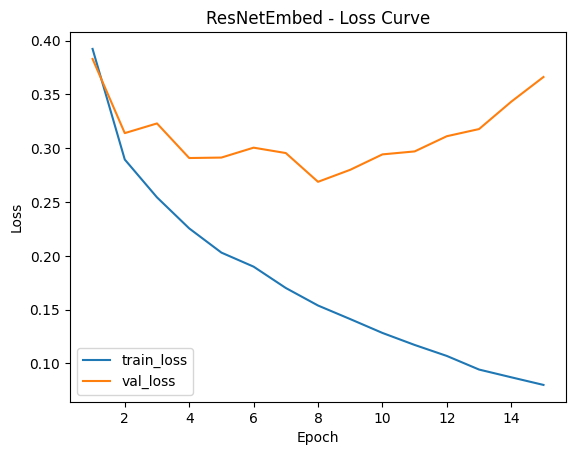

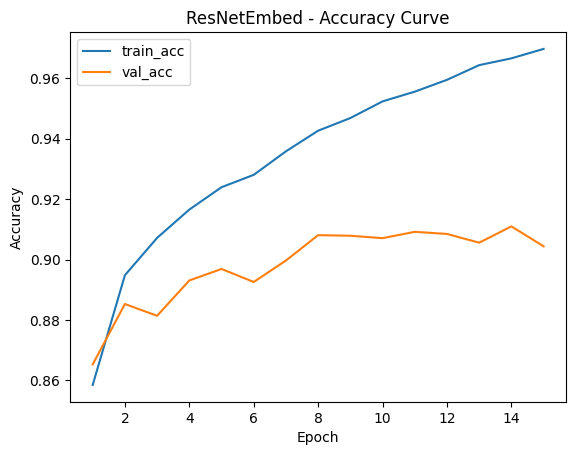

In [37]:
# 4) Plot train/validation loss & accuracy curves
epochs = range(1, num_epochs+1)

plt.figure()
plt.plot(epochs, history_e['train_loss'], label='train_loss')
plt.plot(epochs, history_e['val_loss'],   label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('ResNetEmbed - Loss Curve')
plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history_e['train_acc'], label='train_acc')
plt.plot(epochs, history_e['val_acc'],   label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('ResNetEmbed - Accuracy Curve')
plt.legend(); plt.show()


In [38]:
# 5) Initial metrics summary & design contributions
size_e = get_model_size_mb(model_e)
inf_e  = measure_inference_time(model_e, test_loader)

print("=== ResNetEmbed Initial Metrics ===")
print(f"Val Acc: {history_e['val_acc'][-1]:.4f}, Val F1: {history_e['val_f1'][-1]:.4f}")
print(f"Model Size: {size_e:.2f} MB")
print(f"Inference Time: {inf_e:.2f} ms/batch\n")
print("Design contributions:")
print(" • Accuracy: residual‐backbone + embed layer → richer features")
print(" • Time: deeper net but low‐dim embedding reduces head cost")
print(" • Memory: small classifier head (embed_dim=64)")
print(" • Power/Energy: standard ResNet cost; head compute trimmed")
print(" • Privacy/Security: end‐to‐end on‐device training")


=== ResNetEmbed Initial Metrics ===
Val Acc: 0.9044, Val F1: 0.9050
Model Size: 44.89 MB
Inference Time: 2.84 ms/batch

Design contributions:
 • Accuracy: residual‐backbone + embed layer → richer features
 • Time: deeper net but low‐dim embedding reduces head cost
 • Memory: small classifier head (embed_dim=64)
 • Power/Energy: standard ResNet cost; head compute trimmed
 • Privacy/Security: end‐to‐end on‐device training


In [39]:
# 6) Hyperparameter search setup for ResNetEmbed
search_space_e = {
    'lr': [1e-4, 5e-4, 1e-3],
    'batch_size': [32, 64, 128],
    'embedding_dim': [32, 64]
}


In [ ]:
# 7) Hyperparameter search loop
from itertools import product
import pandas as pd

results_e = []
best_acc_e = 0.0
best_cfg_e = None

for lr, bs, emb in product(search_space_e['lr'],
                           search_space_e['batch_size'],
                           search_space_e['embedding_dim']):
    # reload data & model
    tl = DataLoader(train_ds, batch_size=bs, shuffle=True)
    vl = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    m = ResNetEmbed(embedding_dim=emb).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    # quick training
    for _ in range(5): train_epoch(m, tl, opt, criterion)
    _, acc, f1 = eval_model(m, vl, criterion)
    results_e.append({'lr':lr, 'batch_size':bs, 'embedding_dim':emb, 'acc':acc, 'f1':f1})
    if acc > best_acc_e:
        best_acc_e = acc
        best_cfg_e = (lr, bs, emb)

df_e = pd.DataFrame(results_e)
print("Best cfg:", best_cfg_e, "→ acc:", best_acc_e)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  w

Best cfg: (0.0005, 32, 64) → acc: 0.9031


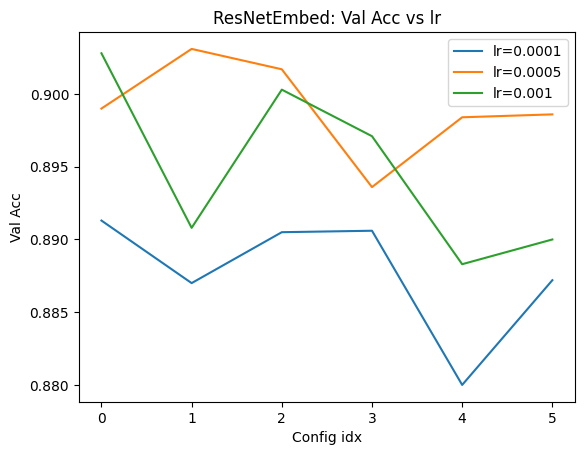

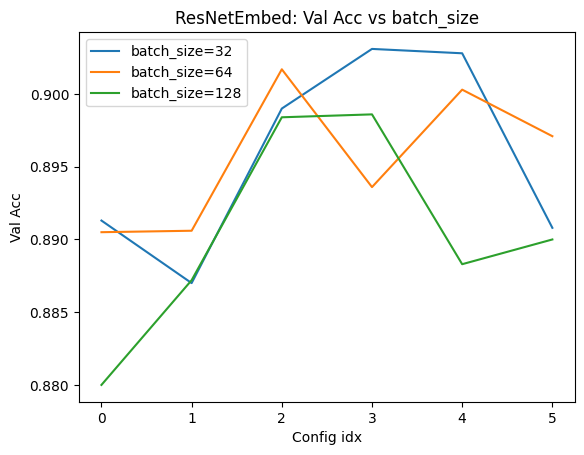

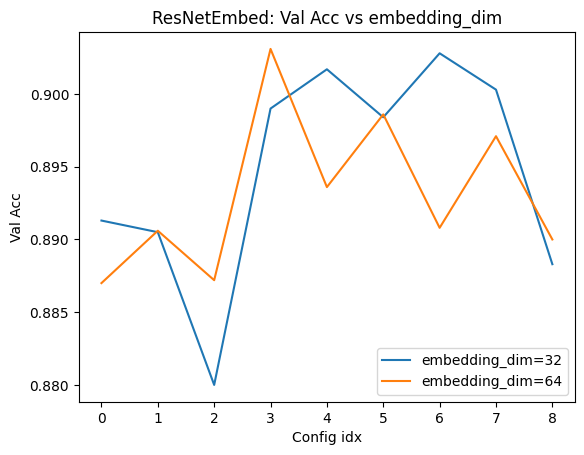

In [41]:
# 8) Visualize hyperparameter effects on validation accuracy
for param in ['lr', 'batch_size', 'embedding_dim']:
    plt.figure()
    for val in df_e[param].unique():
        sub = df_e[df_e[param]==val]
        plt.plot(sub['acc'].values, label=f"{param}={val}")
    plt.title(f"ResNetEmbed: Val Acc vs {param}")
    plt.xlabel('Config idx'); plt.ylabel('Val Acc')
    plt.legend(); plt.show()


In [42]:
# 9) Retrain ResNetEmbed with best hyperparameters
best_lr_e, best_bs_e, best_emb_e = best_cfg_e
print(f"Retraining with lr={best_lr_e}, batch_size={best_bs_e}, embed_dim={best_emb_e}")

train_loader = DataLoader(train_ds, batch_size=best_bs_e, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=best_bs_e, shuffle=False)
model_opt_e   = ResNetEmbed(embedding_dim=best_emb_e).to(device)
optimizer_opt = optim.Adam(model_opt_e.parameters(), lr=best_lr_e)

history_opt_e = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
start_time = time.time()

for ep in range(1, num_epochs+1):
    tr_l, tr_a = train_epoch(model_opt_e, train_loader, optimizer_opt, criterion)
    vl, va, vf = eval_model(model_opt_e, test_loader,      criterion)
    history_opt_e['train_loss'].append(tr_l)
    history_opt_e['train_acc'].append(tr_a)
    history_opt_e['val_loss'].append(vl)
    history_opt_e['val_acc'].append(va)
    history_opt_e['val_f1'].append(vf)
    print(f"[Opt] Epoch {ep}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")

train_time_opt_e = time.time() - start_time


Retraining with lr=0.0005, batch_size=32, embed_dim=64


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


[Opt] Epoch 1: train_acc=0.8396, val_acc=0.8742, val_f1=0.8730
[Opt] Epoch 2: train_acc=0.8857, val_acc=0.8859, val_f1=0.8862
[Opt] Epoch 3: train_acc=0.9014, val_acc=0.8920, val_f1=0.8910
[Opt] Epoch 4: train_acc=0.9096, val_acc=0.8969, val_f1=0.8957
[Opt] Epoch 5: train_acc=0.9194, val_acc=0.8967, val_f1=0.8968
[Opt] Epoch 6: train_acc=0.9264, val_acc=0.9067, val_f1=0.9068
[Opt] Epoch 7: train_acc=0.9326, val_acc=0.9041, val_f1=0.9033
[Opt] Epoch 8: train_acc=0.9389, val_acc=0.9056, val_f1=0.9051
[Opt] Epoch 9: train_acc=0.9457, val_acc=0.9116, val_f1=0.9112
[Opt] Epoch 10: train_acc=0.9489, val_acc=0.9060, val_f1=0.9069
[Opt] Epoch 11: train_acc=0.9541, val_acc=0.9044, val_f1=0.9035
[Opt] Epoch 12: train_acc=0.9598, val_acc=0.9062, val_f1=0.9064
[Opt] Epoch 13: train_acc=0.9619, val_acc=0.9115, val_f1=0.9112
[Opt] Epoch 14: train_acc=0.9659, val_acc=0.9108, val_f1=0.9093
[Opt] Epoch 15: train_acc=0.9690, val_acc=0.9146, val_f1=0.9139


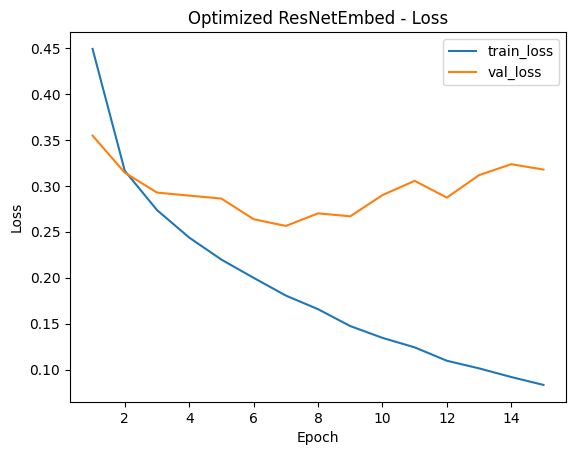

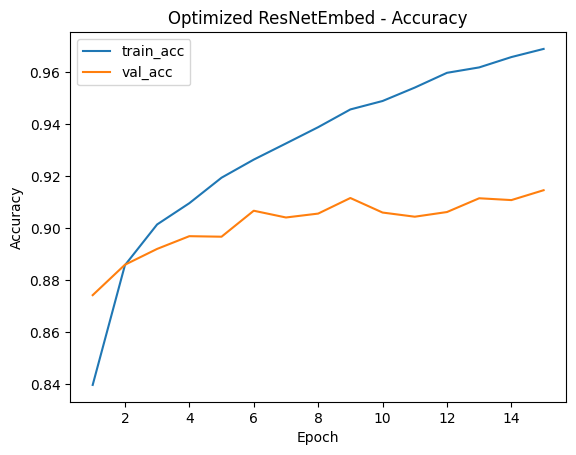

In [43]:
# 10) Plot optimized ResNetEmbed curves
plt.figure()
plt.plot(epochs, history_opt_e['train_loss'], label='train_loss')
plt.plot(epochs, history_opt_e['val_loss'],   label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Optimized ResNetEmbed - Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history_opt_e['train_acc'], label='train_acc')
plt.plot(epochs, history_opt_e['val_acc'],   label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Optimized ResNetEmbed - Accuracy'); plt.legend(); plt.show()


In [44]:
# 11) Optimized metrics summary
size_opt_e = get_model_size_mb(model_opt_e)
inf_opt_e  = measure_inference_time(model_opt_e, test_loader)

print("=== Optimized ResNetEmbed Metrics ===")
print(f"Val Acc: {history_opt_e['val_acc'][-1]:.4f}, Val F1: {history_opt_e['val_f1'][-1]:.4f}")
print(f"Model Size: {size_opt_e:.2f} MB")
print(f"Inference Time: {inf_opt_e:.2f} ms/batch")
print(f"Total Train Time: {train_time_opt_e:.1f} s")


=== Optimized ResNetEmbed Metrics ===
Val Acc: 0.9146, Val F1: 0.9139
Model Size: 44.89 MB
Inference Time: 2.45 ms/batch
Total Train Time: 570.2 s


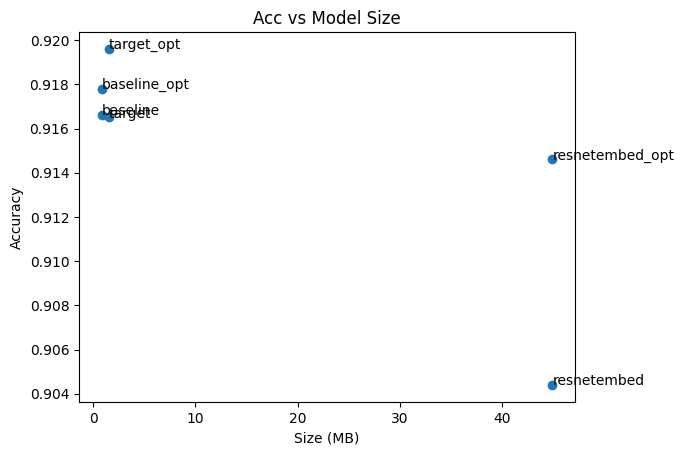

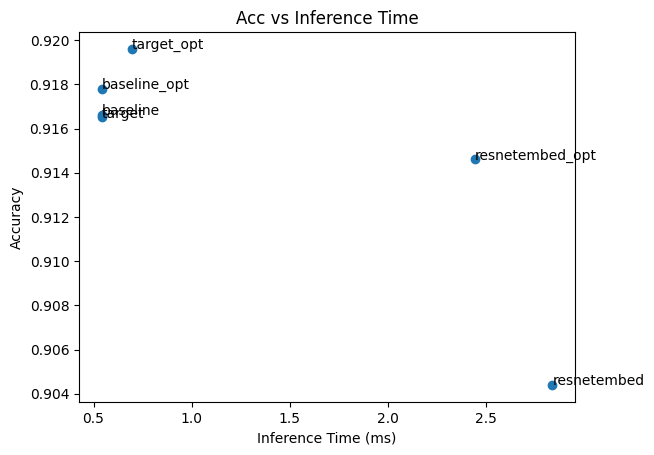

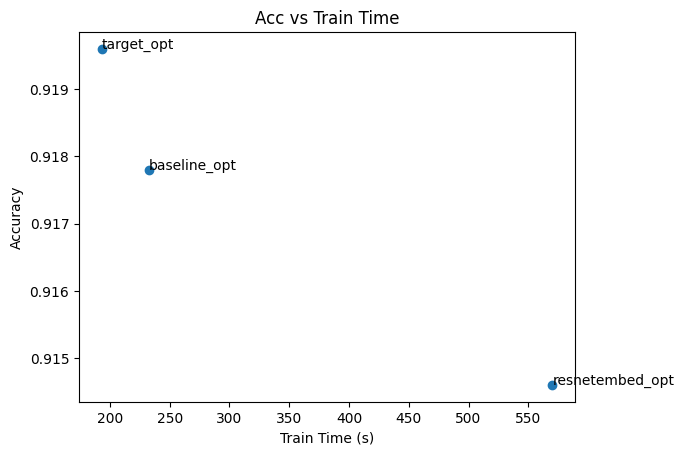

In [45]:
# 12) Combined trade-off scatter plots (all models)
metrics_all = pd.DataFrame([
    {'model':'baseline',       'acc':history['val_acc'][-1],        'size_mb':size_mb,       'inf_ms':inf_ms,        'train_s': None},
    {'model':'baseline_opt',   'acc':history_opt['val_acc'][-1],    'size_mb':size_mb,       'inf_ms':inf_ms,        'train_s': train_time_opt},
    {'model':'target',         'acc':history_t['val_acc'][-1],      'size_mb':size_t,        'inf_ms':inf_t,         'train_s': None},
    {'model':'target_opt',     'acc':history_opt_t['val_acc'][-1],  'size_mb':size_opt_t,    'inf_ms':inf_opt_t,     'train_s': train_time_opt_t},
    {'model':'resnetembed',    'acc':history_e['val_acc'][-1],      'size_mb':size_e,        'inf_ms':inf_e,         'train_s': None},
    {'model':'resnetembed_opt','acc':history_opt_e['val_acc'][-1], 'size_mb':size_opt_e,    'inf_ms':inf_opt_e,     'train_s': train_time_opt_e},
])

# Accuracy vs Model Size
plt.figure()
plt.scatter(metrics_all['size_mb'], metrics_all['acc'])
for _,r in metrics_all.iterrows(): plt.text(r['size_mb'], r['acc'], r['model'])
plt.xlabel('Size (MB)'); plt.ylabel('Accuracy'); plt.title('Acc vs Model Size'); plt.show()

# Accuracy vs Inference Time
plt.figure()
plt.scatter(metrics_all['inf_ms'], metrics_all['acc'])
for _,r in metrics_all.iterrows(): plt.text(r['inf_ms'], r['acc'], r['model'])
plt.xlabel('Inference Time (ms)'); plt.ylabel('Accuracy'); plt.title('Acc vs Inference Time'); plt.show()

# Accuracy vs Training Time (optimized only)
opt_df = metrics_all.dropna(subset=['train_s'])
plt.figure()
plt.scatter(opt_df['train_s'], opt_df['acc'])
for _,r in opt_df.iterrows(): plt.text(r['train_s'], r['acc'], r['model'])
plt.xlabel('Train Time (s)'); plt.ylabel('Accuracy'); plt.title('Acc vs Train Time'); plt.show()


In [49]:
# 1) DenseNetModel class definition (with pool adjustments)
from torchvision.models import densenet121

class DenseNetModel(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0):
        super().__init__()
        backbone = densenet121(pretrained=False)

        # adapt to 1-channel input
        backbone.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # disable initial 7×7 pooling
        backbone.features.pool0 = nn.Identity()
        # disable the last transition pool to avoid 0×0 spatial
        backbone.features.transition3.pool = nn.Identity()

        self.features   = backbone.features
        in_feats        = backbone.classifier.in_features
        self.dropout    = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.classifier = nn.Linear(in_feats, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1,1)).view(x.size(0), -1)
        x = self.dropout(x)
        return self.classifier(x)


In [50]:
# 2) Instantiate DenseNetModel on device
model_d = DenseNetModel(dropout=0.0).to(device)
print(model_d)


DenseNetModel(
  (features): Sequential(
    (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): Identity()
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(96, 128, ker

In [51]:
# 3) One-shot training & evaluation (5 epochs)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_d.parameters(), lr=1e-3)
num_epochs = 15

history_d = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

for ep in range(1, num_epochs+1):
    tr_l, tr_a = train_epoch(model_d, train_loader, optimizer, criterion)
    vl, va, vf = eval_model(model_d, test_loader,  criterion)
    history_d['train_loss'].append(tr_l)
    history_d['train_acc'].append(tr_a)
    history_d['val_loss'].append(vl)
    history_d['val_acc'].append(va)
    history_d['val_f1'].append(vf)
    print(f"DenseNetModel Epoch {ep}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")


DenseNetModel Epoch 1: train_acc=0.8420, val_acc=0.8842, val_f1=0.8849
DenseNetModel Epoch 2: train_acc=0.8938, val_acc=0.8989, val_f1=0.8994
DenseNetModel Epoch 3: train_acc=0.9118, val_acc=0.9086, val_f1=0.9070
DenseNetModel Epoch 4: train_acc=0.9216, val_acc=0.9140, val_f1=0.9125
DenseNetModel Epoch 5: train_acc=0.9307, val_acc=0.9176, val_f1=0.9182
DenseNetModel Epoch 6: train_acc=0.9396, val_acc=0.9221, val_f1=0.9224
DenseNetModel Epoch 7: train_acc=0.9463, val_acc=0.9214, val_f1=0.9213
DenseNetModel Epoch 8: train_acc=0.9531, val_acc=0.9211, val_f1=0.9208
DenseNetModel Epoch 9: train_acc=0.9597, val_acc=0.9239, val_f1=0.9234
DenseNetModel Epoch 10: train_acc=0.9651, val_acc=0.9210, val_f1=0.9211
DenseNetModel Epoch 11: train_acc=0.9706, val_acc=0.9269, val_f1=0.9264
DenseNetModel Epoch 12: train_acc=0.9743, val_acc=0.9251, val_f1=0.9250
DenseNetModel Epoch 13: train_acc=0.9775, val_acc=0.9281, val_f1=0.9276
DenseNetModel Epoch 14: train_acc=0.9801, val_acc=0.9208, val_f1=0.9208
D

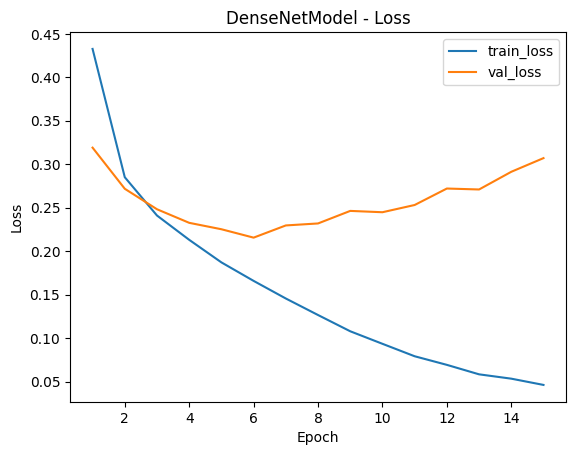

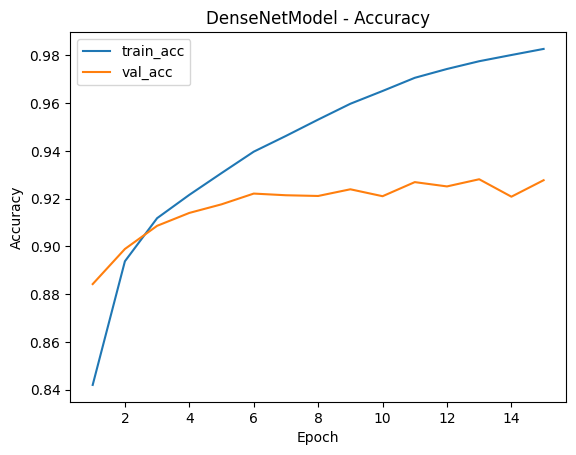

In [52]:
# 4) Plot training vs validation curves
epochs = range(1, num_epochs+1)

plt.figure()
plt.plot(epochs, history_d['train_loss'], label='train_loss')
plt.plot(epochs, history_d['val_loss'],   label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('DenseNetModel - Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history_d['train_acc'], label='train_acc')
plt.plot(epochs, history_d['val_acc'],   label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('DenseNetModel - Accuracy'); plt.legend(); plt.show()


In [53]:
# 5) Initial metrics & design contributions
size_d = get_model_size_mb(model_d)
inf_d  = measure_inference_time(model_d, test_loader)

print("=== DenseNetModel Initial Metrics ===")
print(f"Val Acc: {history_d['val_acc'][-1]:.4f}, Val F1: {history_d['val_f1'][-1]:.4f}")
print(f"Size: {size_d:.2f} MB, Inference: {inf_d:.2f} ms/batch\n")
print("Design contributions:")
print(" • Accuracy: dense connectivity → rich feature reuse")
print(" • Time: disabled extra pools keeps feature maps small")
print(" • Memory: compact backbone + optional dropout")
print(" • Power/Energy: fewer spatial ops than default")
print(" • Privacy/Security: self-contained, no external data")


=== DenseNetModel Initial Metrics ===
Val Acc: 0.9277, Val F1: 0.9279
Size: 28.39 MB, Inference: 14.69 ms/batch

Design contributions:
 • Accuracy: dense connectivity → rich feature reuse
 • Time: disabled extra pools keeps feature maps small
 • Memory: compact backbone + optional dropout
 • Power/Energy: fewer spatial ops than default
 • Privacy/Security: self-contained, no external data


In [54]:
# 6) Hyperparameter search space
search_space_d = {
    'lr': [1e-4, 5e-4, 1e-3],
    'batch_size': [32, 64, 128],
    'dropout': [0.0, 0.2, 0.5]
}


In [56]:
# 7) Quick 5-epoch HP search
results_d = []
best_acc_d = 0.0
best_cfg_d = None

for lr, bs, do in product(search_space_d['lr'],
                          search_space_d['batch_size'],
                          search_space_d['dropout']):
    tl = DataLoader(train_ds, batch_size=bs, shuffle=True)
    vl = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    m = DenseNetModel(dropout=do).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    for _ in range(5):
        train_epoch(m, tl, opt, criterion)
    _, acc, f1 = eval_model(m, vl, criterion)
    results_d.append({'lr':lr, 'batch_size':bs, 'dropout':do, 'acc':acc, 'f1':f1})
    if acc > best_acc_d:
        best_acc_d = acc
        best_cfg_d = (lr, bs, do)

df_d = pd.DataFrame(results_d)
print("Best cfg:", best_cfg_d, "→ acc:", best_acc_d)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  w

Best cfg: (0.001, 32, 0.2) → acc: 0.9222


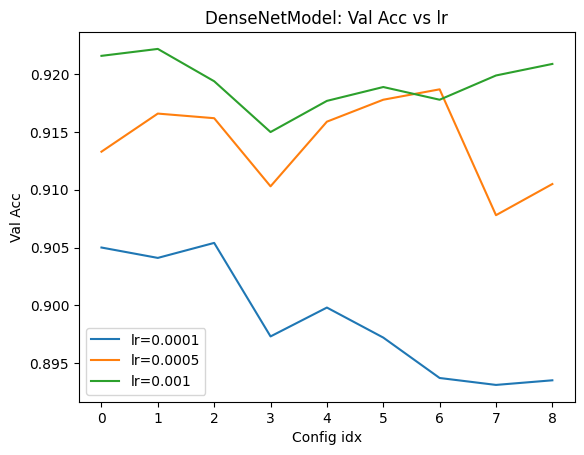

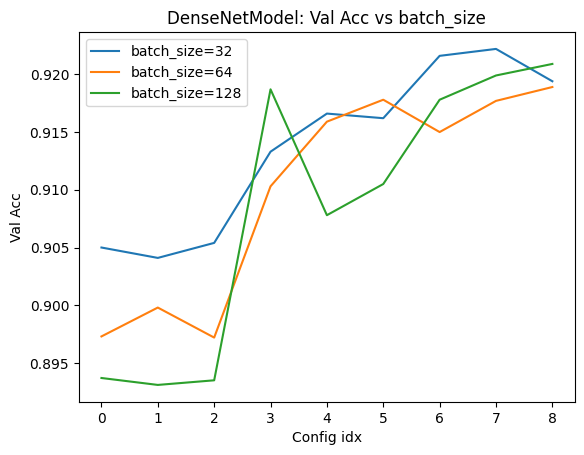

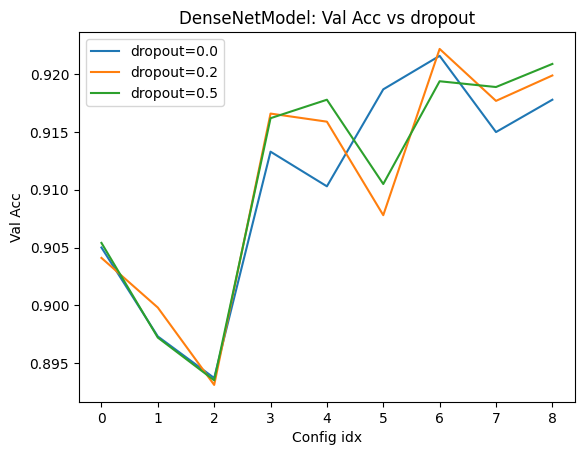

In [57]:
# 8) Plot HP effects on val accuracy
for param in ['lr', 'batch_size', 'dropout']:
    plt.figure()
    for val in df_d[param].unique():
        sub = df_d[df_d[param]==val]
        plt.plot(sub['acc'].values, label=f"{param}={val}")
    plt.title(f"DenseNetModel: Val Acc vs {param}")
    plt.xlabel('Config idx'); plt.ylabel('Val Acc')
    plt.legend(); plt.show()


In [58]:
# 9) Retrain with best hyperparameters
best_lr_d, best_bs_d, best_do_d = best_cfg_d
print(f"Retraining lr={best_lr_d}, batch_size={best_bs_d}, dropout={best_do_d}")

train_loader = DataLoader(train_ds, batch_size=best_bs_d, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=best_bs_d, shuffle=False)
model_opt_d   = DenseNetModel(dropout=best_do_d).to(device)
optimizer_opt = optim.Adam(model_opt_d.parameters(), lr=best_lr_d)

history_opt_d = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
start_time = time.time()

for ep in range(1, num_epochs+1):
    tr_l, tr_a = train_epoch(model_opt_d, train_loader, optimizer_opt, criterion)
    vl, va, vf = eval_model(model_opt_d, test_loader,      criterion)
    history_opt_d['train_loss'].append(tr_l)
    history_opt_d['train_acc'].append(tr_a)
    history_opt_d['val_loss'].append(vl)
    history_opt_d['val_acc'].append(va)
    history_opt_d['val_f1'].append(vf)
    print(f"[Opt-D] Epoch {ep}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")

train_time_opt_d = time.time() - start_time


Retraining lr=0.001, batch_size=32, dropout=0.2


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


[Opt-D] Epoch 1: train_acc=0.8399, val_acc=0.8734, val_f1=0.8705
[Opt-D] Epoch 2: train_acc=0.8945, val_acc=0.9012, val_f1=0.9007
[Opt-D] Epoch 3: train_acc=0.9101, val_acc=0.9063, val_f1=0.9057
[Opt-D] Epoch 4: train_acc=0.9212, val_acc=0.9104, val_f1=0.9113
[Opt-D] Epoch 5: train_acc=0.9284, val_acc=0.9137, val_f1=0.9137
[Opt-D] Epoch 6: train_acc=0.9371, val_acc=0.9207, val_f1=0.9210
[Opt-D] Epoch 7: train_acc=0.9445, val_acc=0.9227, val_f1=0.9224
[Opt-D] Epoch 8: train_acc=0.9519, val_acc=0.9205, val_f1=0.9204
[Opt-D] Epoch 9: train_acc=0.9572, val_acc=0.9237, val_f1=0.9233
[Opt-D] Epoch 10: train_acc=0.9629, val_acc=0.9292, val_f1=0.9289
[Opt-D] Epoch 11: train_acc=0.9685, val_acc=0.9255, val_f1=0.9255
[Opt-D] Epoch 12: train_acc=0.9731, val_acc=0.9264, val_f1=0.9264
[Opt-D] Epoch 13: train_acc=0.9757, val_acc=0.9262, val_f1=0.9260
[Opt-D] Epoch 14: train_acc=0.9795, val_acc=0.9245, val_f1=0.9241
[Opt-D] Epoch 15: train_acc=0.9828, val_acc=0.9251, val_f1=0.9246


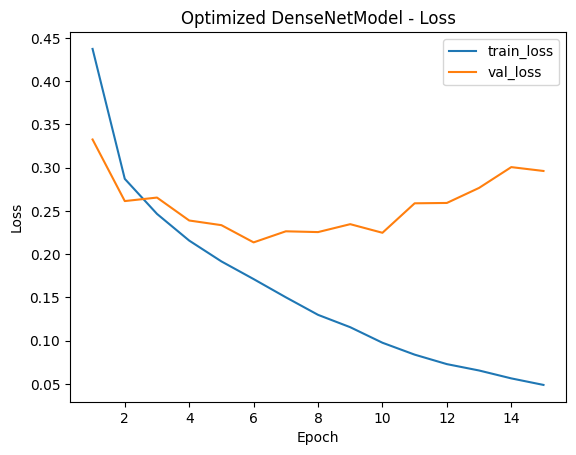

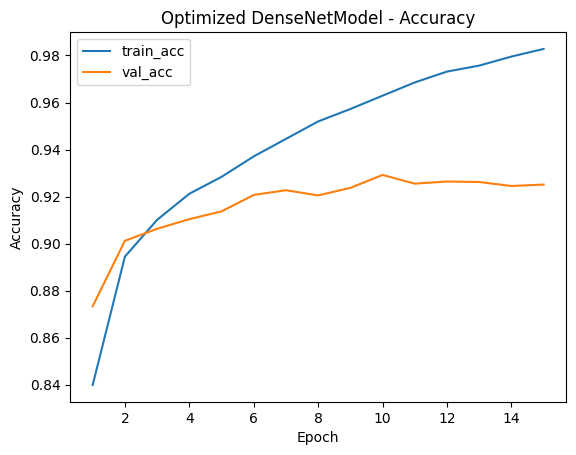

In [59]:
# 10) Plot optimized curves
plt.figure()
plt.plot(epochs, history_opt_d['train_loss'], label='train_loss')
plt.plot(epochs, history_opt_d['val_loss'],   label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Optimized DenseNetModel - Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history_opt_d['train_acc'], label='train_acc')
plt.plot(epochs, history_opt_d['val_acc'],   label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Optimized DenseNetModel - Accuracy'); plt.legend(); plt.show()


In [60]:
# 11) Optimized DenseNetModel metrics
size_opt_d = get_model_size_mb(model_opt_d)
inf_opt_d  = measure_inference_time(model_opt_d, test_loader)

print("=== Optimized DenseNetModel Metrics ===")
print(f"Val Acc: {history_opt_d['val_acc'][-1]:.4f}, Val F1: {history_opt_d['val_f1'][-1]:.4f}")
print(f"Size: {size_opt_d:.2f} MB, Inference: {inf_opt_d:.2f} ms/batch")
print(f"Train Time: {train_time_opt_d:.1f} s")


=== Optimized DenseNetModel Metrics ===
Val Acc: 0.9251, Val F1: 0.9246
Size: 28.39 MB, Inference: 14.85 ms/batch
Train Time: 1730.5 s


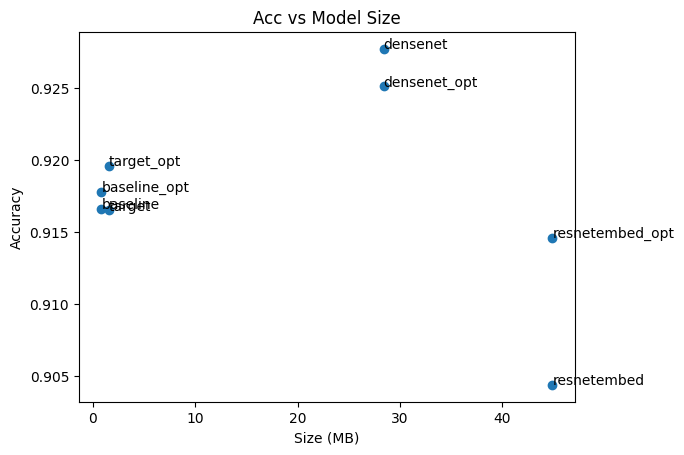

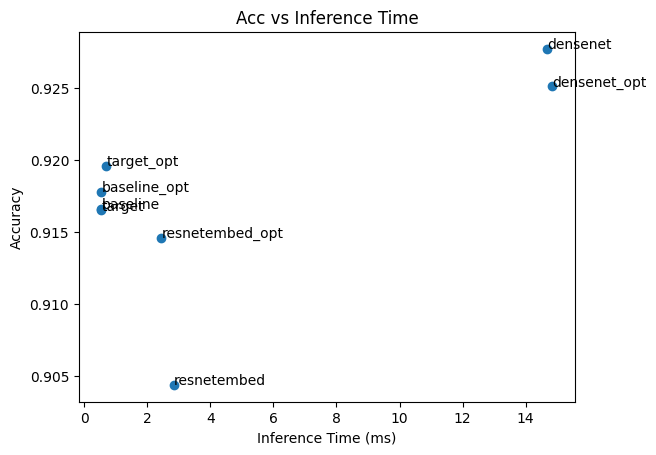

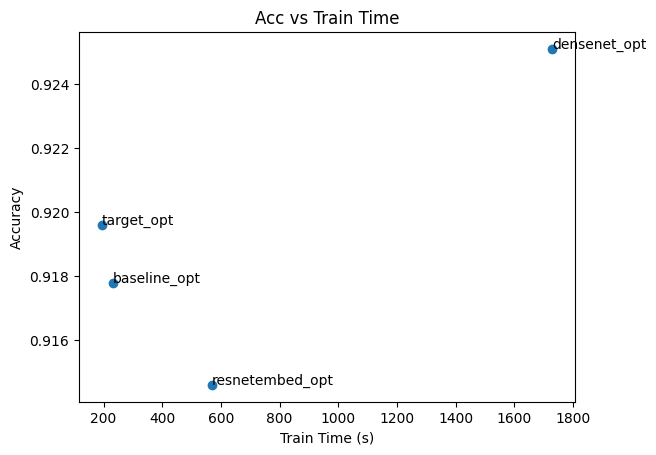

In [61]:
# 12) Combined trade-off plots (all models)
metrics_all = pd.DataFrame([
    {'model':'baseline',         'acc':history['val_acc'][-1],         'size_mb':size_mb,         'inf_ms':inf_ms,        'train_s': None},
    {'model':'baseline_opt',     'acc':history_opt['val_acc'][-1],     'size_mb':size_mb,         'inf_ms':inf_ms,        'train_s': train_time_opt},
    {'model':'target',           'acc':history_t['val_acc'][-1],       'size_mb':size_t,          'inf_ms':inf_t,         'train_s': None},
    {'model':'target_opt',       'acc':history_opt_t['val_acc'][-1],   'size_mb':size_opt_t,      'inf_ms':inf_opt_t,     'train_s': train_time_opt_t},
    {'model':'resnetembed',      'acc':history_e['val_acc'][-1],       'size_mb':size_e,          'inf_ms':inf_e,         'train_s': None},
    {'model':'resnetembed_opt',  'acc':history_opt_e['val_acc'][-1],   'size_mb':size_opt_e,      'inf_ms':inf_opt_e,     'train_s': train_time_opt_e},
    {'model':'densenet',         'acc':history_d['val_acc'][-1],       'size_mb':size_d,          'inf_ms':inf_d,         'train_s': None},
    {'model':'densenet_opt',     'acc':history_opt_d['val_acc'][-1],   'size_mb':size_opt_d,      'inf_ms':inf_opt_d,     'train_s': train_time_opt_d},
])

# Accuracy vs Model Size
plt.figure()
plt.scatter(metrics_all['size_mb'], metrics_all['acc'])
for _,r in metrics_all.iterrows(): plt.text(r['size_mb'], r['acc'], r['model'])
plt.xlabel('Size (MB)'); plt.ylabel('Accuracy'); plt.title('Acc vs Model Size'); plt.show()

# Accuracy vs Inference Time
plt.figure()
plt.scatter(metrics_all['inf_ms'], metrics_all['acc'])
for _,r in metrics_all.iterrows(): plt.text(r['inf_ms'], r['acc'], r['model'])
plt.xlabel('Inference Time (ms)'); plt.ylabel('Accuracy'); plt.title('Acc vs Inference Time'); plt.show()

# Accuracy vs Training Time (optimized only)
opt_df = metrics_all.dropna(subset=['train_s'])
plt.figure()
plt.scatter(opt_df['train_s'], opt_df['acc'])
for _,r in opt_df.iterrows(): plt.text(r['train_s'], r['acc'], r['model'])
plt.xlabel('Train Time (s)'); plt.ylabel('Accuracy'); plt.title('Acc vs Train Time'); plt.show()


In [62]:
# 1) DepthwiseSeparableCNN class definition
class DepthwiseSeparableCNN(nn.Module):
    def __init__(self, num_classes=10, hidden_dim=64, dropout=0.0):
        super().__init__()
        # depthwise separable conv block
        self.conv_dw1 = nn.Conv2d(1, 1, kernel_size=3, padding=1, groups=1)
        self.conv_pw1 = nn.Conv2d(1, hidden_dim, kernel_size=1)
        self.conv_dw2 = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1, groups=hidden_dim)
        self.conv_pw2 = nn.Conv2d(hidden_dim, hidden_dim*2, kernel_size=1)
        self.pool     = nn.MaxPool2d(2,2)
        self.dropout  = nn.Dropout(dropout) if dropout>0 else nn.Identity()
        self.fc       = nn.Linear((hidden_dim*2)*(7)*(7), num_classes)

    def forward(self, x):
        x = F.relu(self.conv_pw1(self.conv_dw1(x)))  # 28→28
        x = self.pool(x)                             # 28→14
        x = F.relu(self.conv_pw2(self.conv_dw2(x)))  # 14→14
        x = self.pool(x)                             # 14→7
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)


In [63]:
# 2) Instantiate DepthwiseSeparableCNN
model_ds = DepthwiseSeparableCNN(hidden_dim=64, dropout=0.0).to(device)
print(model_ds)


DepthwiseSeparableCNN(
  (conv_dw1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_pw1): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  (conv_dw2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
  (conv_pw2): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Identity()
  (fc): Linear(in_features=6272, out_features=10, bias=True)
)


In [64]:
# 3) One-shot training & evaluation (5 epochs)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ds.parameters(), lr=1e-3)
num_epochs = 15

history_ds = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

for ep in range(1, num_epochs+1):
    tr_l, tr_a = train_epoch(model_ds, train_loader, optimizer, criterion)
    vl, va, vf = eval_model(model_ds, test_loader,  criterion)
    history_ds['train_loss'].append(tr_l)
    history_ds['train_acc'].append(tr_a)
    history_ds['val_loss'].append(vl)
    history_ds['val_acc'].append(va)
    history_ds['val_f1'].append(vf)
    print(f"DepthwiseSepCNN Epoch {ep}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")


DepthwiseSepCNN Epoch 1: train_acc=0.8386, val_acc=0.8673, val_f1=0.8662
DepthwiseSepCNN Epoch 2: train_acc=0.8852, val_acc=0.8912, val_f1=0.8898
DepthwiseSepCNN Epoch 3: train_acc=0.8980, val_acc=0.8844, val_f1=0.8820
DepthwiseSepCNN Epoch 4: train_acc=0.9068, val_acc=0.8884, val_f1=0.8896
DepthwiseSepCNN Epoch 5: train_acc=0.9143, val_acc=0.8912, val_f1=0.8902
DepthwiseSepCNN Epoch 6: train_acc=0.9204, val_acc=0.9000, val_f1=0.8994
DepthwiseSepCNN Epoch 7: train_acc=0.9252, val_acc=0.8986, val_f1=0.8988
DepthwiseSepCNN Epoch 8: train_acc=0.9307, val_acc=0.9008, val_f1=0.9006
DepthwiseSepCNN Epoch 9: train_acc=0.9343, val_acc=0.9024, val_f1=0.9023
DepthwiseSepCNN Epoch 10: train_acc=0.9389, val_acc=0.8999, val_f1=0.9004
DepthwiseSepCNN Epoch 11: train_acc=0.9426, val_acc=0.9033, val_f1=0.9029
DepthwiseSepCNN Epoch 12: train_acc=0.9459, val_acc=0.8978, val_f1=0.8981
DepthwiseSepCNN Epoch 13: train_acc=0.9484, val_acc=0.9034, val_f1=0.9036
DepthwiseSepCNN Epoch 14: train_acc=0.9514, val

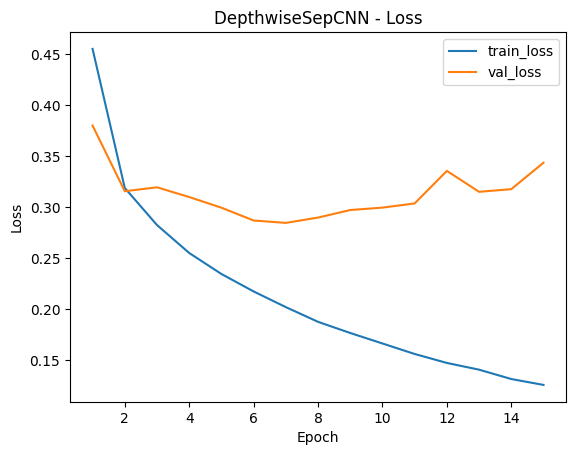

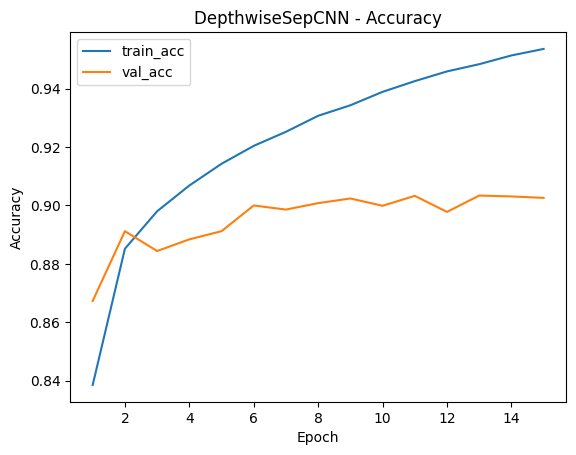

In [65]:
# 4) Plot train/validation curves
epochs = range(1, num_epochs+1)

plt.figure()
plt.plot(epochs, history_ds['train_loss'], label='train_loss')
plt.plot(epochs, history_ds['val_loss'],   label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('DepthwiseSepCNN - Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history_ds['train_acc'], label='train_acc')
plt.plot(epochs, history_ds['val_acc'],   label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('DepthwiseSepCNN - Accuracy'); plt.legend(); plt.show()


In [66]:
# 5) Initial metrics & design contributions
size_ds = get_model_size_mb(model_ds)
inf_ds  = measure_inference_time(model_ds, test_loader)

print("=== DepthwiseSepCNN Initial Metrics ===")
print(f"Val Acc: {history_ds['val_acc'][-1]:.4f}, Val F1: {history_ds['val_f1'][-1]:.4f}")
print(f"Size: {size_ds:.2f} MB, Inference: {inf_ds:.2f} ms/batch\n")
print("Design contributions:")
print(" • Accuracy: separable conv reduces overfitting")
print(" • Time: depthwise convs cut FLOPs significantly")
print(" • Memory: fewer parameters in separable blocks")
print(" • Power/Energy: low compute cost per image")
print(" • Privacy/Security: standalone, no external data")


=== DepthwiseSepCNN Initial Metrics ===
Val Acc: 0.9026, Val F1: 0.9027
Size: 0.29 MB, Inference: 0.53 ms/batch

Design contributions:
 • Accuracy: separable conv reduces overfitting
 • Time: depthwise convs cut FLOPs significantly
 • Memory: fewer parameters in separable blocks
 • Power/Energy: low compute cost per image
 • Privacy/Security: standalone, no external data


In [67]:
# 6) Hyperparameter search space
search_space_ds = {
    'lr': [1e-4, 5e-4, 1e-3],
    'batch_size': [32, 64, 128],
    'hidden_dim': [32, 64, 128],
    'dropout': [0.0, 0.3, 0.5]
}


In [68]:
# 7) Quick 3-epoch hyperparameter search
results_ds = []
best_acc_ds = 0.0
best_cfg_ds = None

for lr, bs, hd, do in product(search_space_ds['lr'],
                              search_space_ds['batch_size'],
                              search_space_ds['hidden_dim'],
                              search_space_ds['dropout']):
    tl = DataLoader(train_ds, batch_size=bs, shuffle=True)
    vl = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    m = DepthwiseSeparableCNN(hidden_dim=hd, dropout=do).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    for _ in range(3):
        train_epoch(m, tl, opt, criterion)
    _, acc, f1 = eval_model(m, vl, criterion)
    results_ds.append({'lr':lr, 'batch_size':bs, 'hidden_dim':hd, 'dropout':do, 'acc':acc, 'f1':f1})
    if acc > best_acc_ds:
        best_acc_ds = acc
        best_cfg_ds = (lr, bs, hd, do)

df_ds = pd.DataFrame(results_ds)
print("Best cfg:", best_cfg_ds, "→ acc:", best_acc_ds)


Best cfg: (0.001, 32, 128, 0.0) → acc: 0.8997


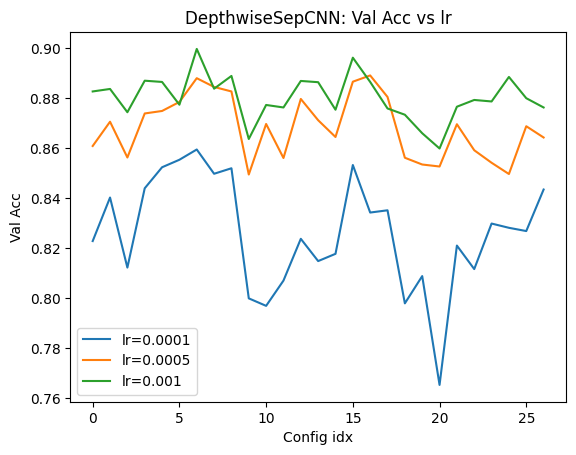

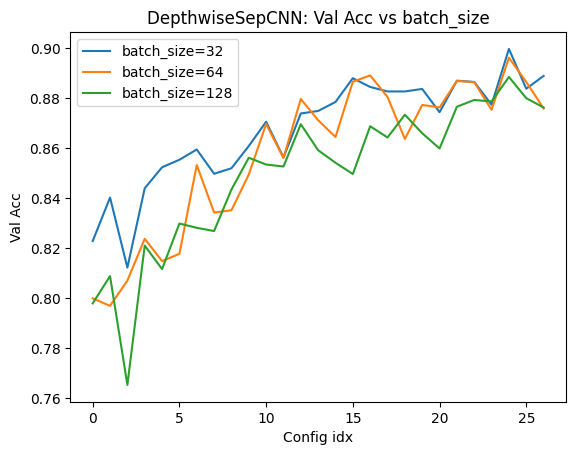

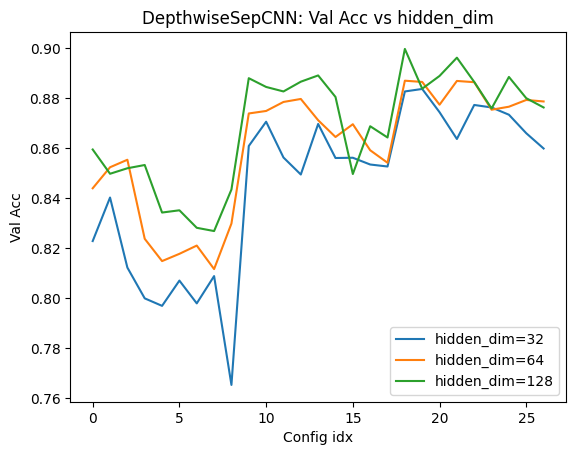

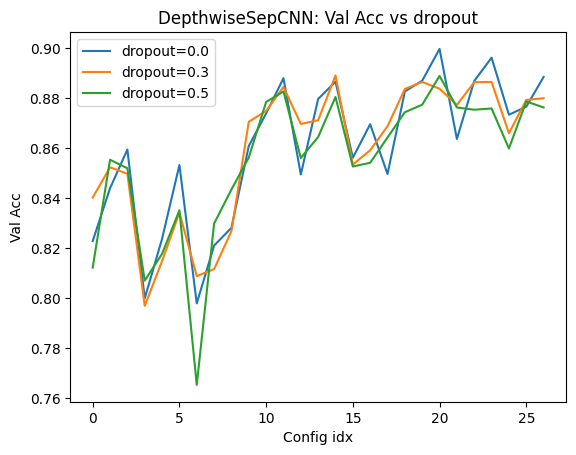

In [69]:
# 8) Visualize hyperparameter effects on accuracy
for param in ['lr', 'batch_size', 'hidden_dim', 'dropout']:
    plt.figure()
    for val in df_ds[param].unique():
        sub = df_ds[df_ds[param]==val]
        plt.plot(sub['acc'].values, label=f"{param}={val}")
    plt.title(f"DepthwiseSepCNN: Val Acc vs {param}")
    plt.xlabel('Config idx'); plt.ylabel('Val Acc')
    plt.legend(); plt.show()


In [70]:
# 9) Retrain with best hyperparameters
best_lr_ds, best_bs_ds, best_hd_ds, best_do_ds = best_cfg_ds
print(f"Retraining lr={best_lr_ds}, batch_size={best_bs_ds}, hidden_dim={best_hd_ds}, dropout={best_do_ds}")

train_loader = DataLoader(train_ds, batch_size=best_bs_ds, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=best_bs_ds, shuffle=False)
model_opt_ds   = DepthwiseSeparableCNN(hidden_dim=best_hd_ds, dropout=best_do_ds).to(device)
optimizer_opt = optim.Adam(model_opt_ds.parameters(), lr=best_lr_ds)

history_opt_ds = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
start_time = time.time()

for ep in range(1, num_epochs+1):
    tr_l, tr_a = train_epoch(model_opt_ds, train_loader, optimizer_opt, criterion)
    vl, va, vf = eval_model(model_opt_ds, test_loader,      criterion)
    history_opt_ds['train_loss'].append(tr_l)
    history_opt_ds['train_acc'].append(tr_a)
    history_opt_ds['val_loss'].append(vl)
    history_opt_ds['val_acc'].append(va)
    history_opt_ds['val_f1'].append(vf)
    print(f"[Opt-DS] Epoch {ep}: train_acc={tr_a:.4f}, val_acc={va:.4f}, val_f1={vf:.4f}")

train_time_opt_ds = time.time() - start_time


Retraining lr=0.001, batch_size=32, hidden_dim=128, dropout=0.0
[Opt-DS] Epoch 1: train_acc=0.8312, val_acc=0.8650, val_f1=0.8589
[Opt-DS] Epoch 2: train_acc=0.8847, val_acc=0.8879, val_f1=0.8866
[Opt-DS] Epoch 3: train_acc=0.8991, val_acc=0.8918, val_f1=0.8909
[Opt-DS] Epoch 4: train_acc=0.9107, val_acc=0.8920, val_f1=0.8921
[Opt-DS] Epoch 5: train_acc=0.9185, val_acc=0.8922, val_f1=0.8923
[Opt-DS] Epoch 6: train_acc=0.9268, val_acc=0.8904, val_f1=0.8893
[Opt-DS] Epoch 7: train_acc=0.9329, val_acc=0.8949, val_f1=0.8945
[Opt-DS] Epoch 8: train_acc=0.9386, val_acc=0.8927, val_f1=0.8920
[Opt-DS] Epoch 9: train_acc=0.9446, val_acc=0.8973, val_f1=0.8976
[Opt-DS] Epoch 10: train_acc=0.9488, val_acc=0.8993, val_f1=0.8997
[Opt-DS] Epoch 11: train_acc=0.9522, val_acc=0.8994, val_f1=0.8991
[Opt-DS] Epoch 12: train_acc=0.9570, val_acc=0.8999, val_f1=0.9001
[Opt-DS] Epoch 13: train_acc=0.9591, val_acc=0.8982, val_f1=0.8977
[Opt-DS] Epoch 14: train_acc=0.9617, val_acc=0.8981, val_f1=0.8973
[Opt-DS

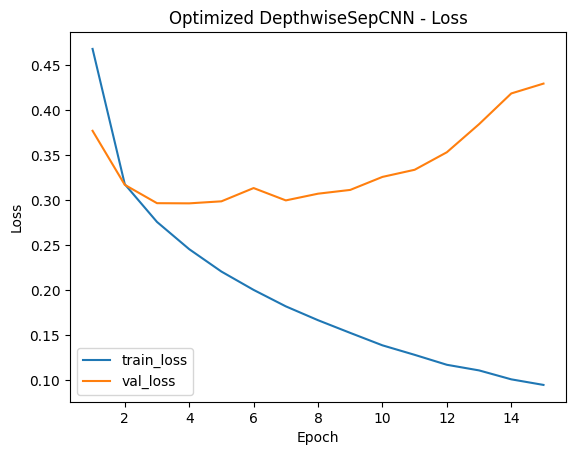

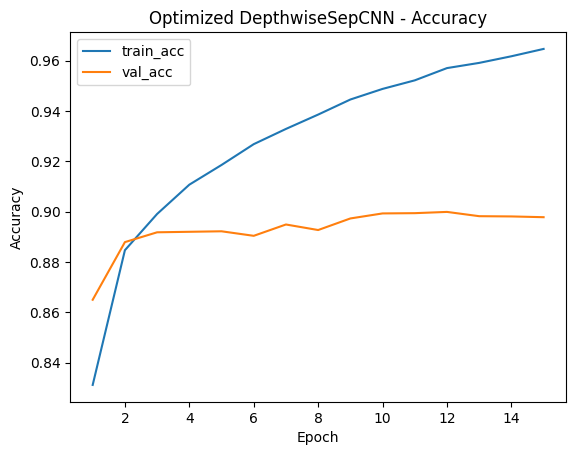

In [71]:
# 10) Plot optimized curves
plt.figure()
plt.plot(epochs, history_opt_ds['train_loss'], label='train_loss')
plt.plot(epochs, history_opt_ds['val_loss'],   label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Optimized DepthwiseSepCNN - Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history_opt_ds['train_acc'], label='train_acc')
plt.plot(epochs, history_opt_ds['val_acc'],   label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Optimized DepthwiseSepCNN - Accuracy'); plt.legend(); plt.show()


In [72]:
# 11) Optimized metrics summary
size_opt_ds = get_model_size_mb(model_opt_ds)
inf_opt_ds  = measure_inference_time(model_opt_ds, test_loader)

print("=== Optimized DepthwiseSepCNN Metrics ===")
print(f"Val Acc: {history_opt_ds['val_acc'][-1]:.4f}, Val F1: {history_opt_ds['val_f1'][-1]:.4f}")
print(f"Size: {size_opt_ds:.2f} MB, Inference: {inf_opt_ds:.2f} ms/batch")
print(f"Train Time: {train_time_opt_ds:.1f} s")


=== Optimized DepthwiseSepCNN Metrics ===
Val Acc: 0.8978, Val F1: 0.8980
Size: 0.64 MB, Inference: 0.49 ms/batch
Train Time: 260.7 s


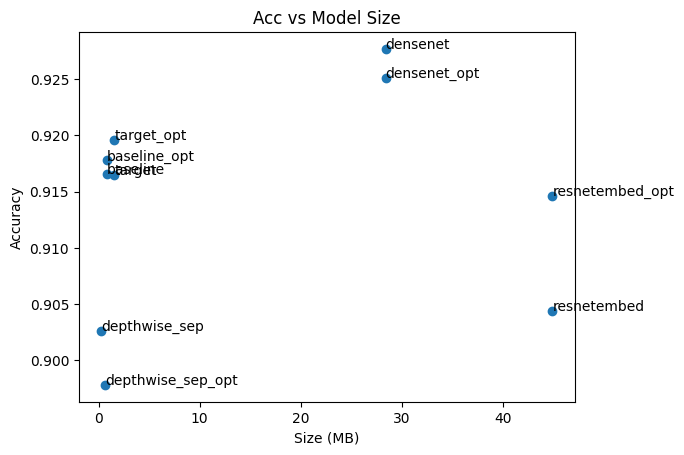

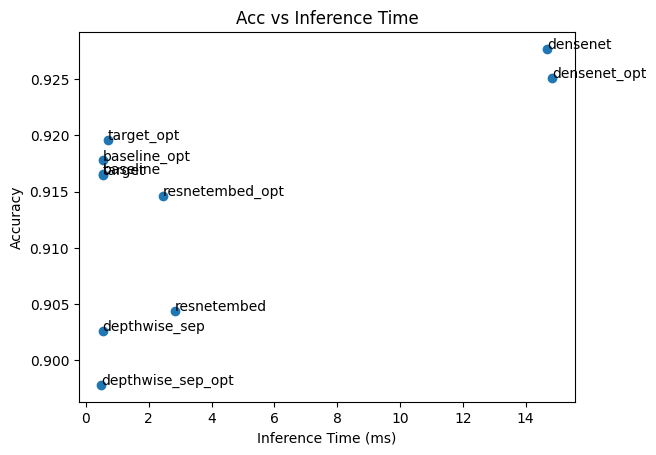

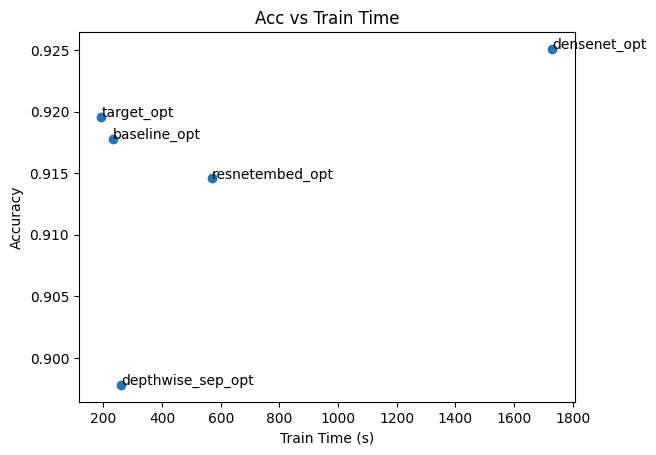

In [75]:
# 12) Combined trade-off scatter plots (all models + this one)
metrics_all = pd.DataFrame([
    {'model':'baseline',           'acc':history['val_acc'][-1],          'size_mb':size_mb,         'inf_ms':inf_ms,        'train_s': None},
    {'model':'baseline_opt',       'acc':history_opt['val_acc'][-1],      'size_mb':size_mb,         'inf_ms':inf_ms,        'train_s': train_time_opt},
    {'model':'target',             'acc':history_t['val_acc'][-1],        'size_mb':size_t,          'inf_ms':inf_t,         'train_s': None},
    {'model':'target_opt',         'acc':history_opt_t['val_acc'][-1],    'size_mb':size_opt_t,      'inf_ms':inf_opt_t,     'train_s': train_time_opt_t},
    {'model':'resnetembed',        'acc':history_e['val_acc'][-1],        'size_mb':size_e,          'inf_ms':inf_e,         'train_s': None},
    {'model':'resnetembed_opt',    'acc':history_opt_e['val_acc'][-1],    'size_mb':size_opt_e,      'inf_ms':inf_opt_e,     'train_s': train_time_opt_e},
    {'model':'densenet',           'acc':history_d['val_acc'][-1],        'size_mb':size_d,          'inf_ms':inf_d,         'train_s': None},
    {'model':'densenet_opt',       'acc':history_opt_d['val_acc'][-1],    'size_mb':size_opt_d,      'inf_ms':inf_opt_d,     'train_s': train_time_opt_d},
    {'model':'depthwise_sep',      'acc':history_ds['val_acc'][-1],       'size_mb':size_ds,         'inf_ms':inf_ds,        'train_s': None},
    {'model':'depthwise_sep_opt',  'acc':history_opt_ds['val_acc'][-1],   'size_mb':size_opt_ds,     'inf_ms':inf_opt_ds,    'train_s': train_time_opt_ds},
])

# Accuracy vs Model Size
plt.figure()
plt.scatter(metrics_all['size_mb'], metrics_all['acc'])
for _,r in metrics_all.iterrows(): plt.text(r['size_mb'], r['acc'], r['model'])
plt.xlabel('Size (MB)'); plt.ylabel('Accuracy'); plt.title('Acc vs Model Size'); plt.show()

# Accuracy vs Inference Time
plt.figure()
plt.scatter(metrics_all['inf_ms'], metrics_all['acc'])
for _,r in metrics_all.iterrows(): plt.text(r['inf_ms'], r['acc'], r['model'])
plt.xlabel('Inference Time (ms)'); plt.ylabel('Accuracy'); plt.title('Acc vs Inference Time'); plt.show()

# Accuracy vs Training Time (optimized only)
opt_df = metrics_all.dropna(subset=['train_s'])
plt.figure()
plt.scatter(opt_df['train_s'], opt_df['acc'])
for _,r in opt_df.iterrows(): plt.text(r['train_s'], r['acc'], r['model'])
plt.xlabel('Train Time (s)'); plt.ylabel('Accuracy'); plt.title('Acc vs Train Time'); plt.show()


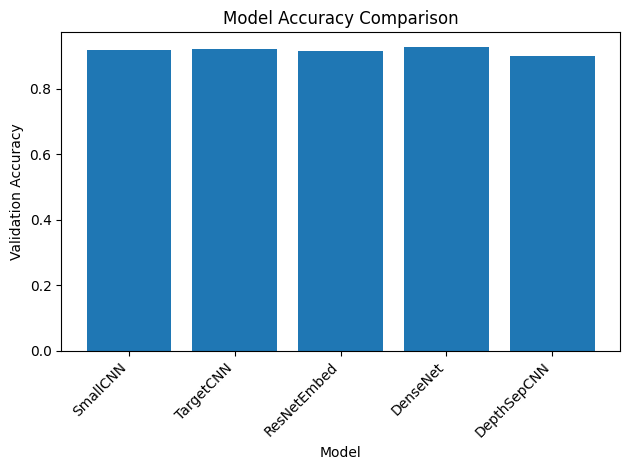

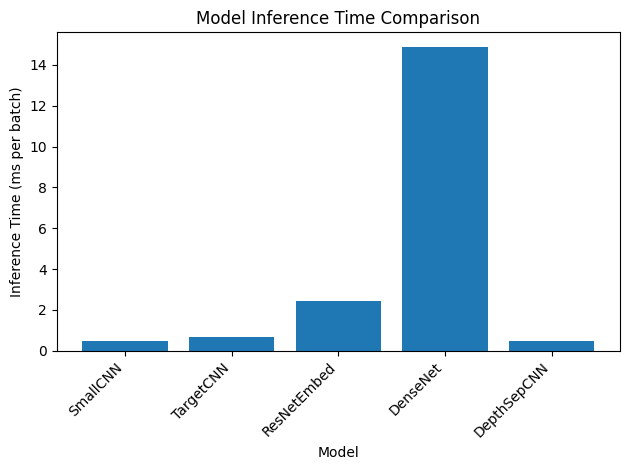

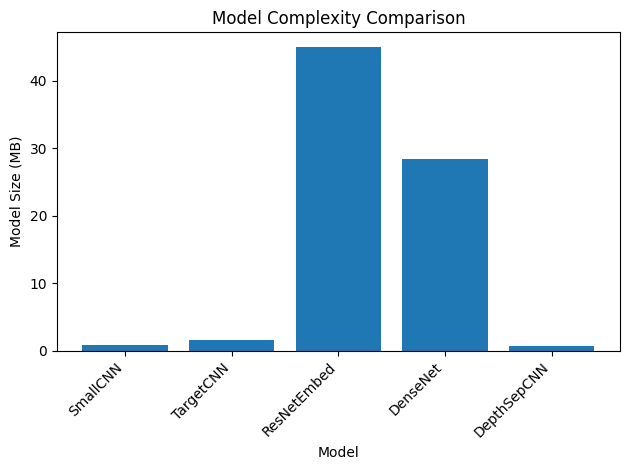

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Rebuild a summary DataFrame of your *optimized* models
metrics_all = pd.DataFrame([
    {
      'Model':      'SmallCNN',
      'Accuracy':   history_opt['val_acc'][-1],
      'Inf_ms':     inf_opt,
      'Size_MB':    size_opt
    },
    {
      'Model':      'TargetCNN',
      'Accuracy':   history_opt_t['val_acc'][-1],
      'Inf_ms':     inf_opt_t,
      'Size_MB':    size_opt_t
    },
    {
      'Model':      'ResNetEmbed',
      'Accuracy':   history_opt_e['val_acc'][-1],
      'Inf_ms':     inf_opt_e,
      'Size_MB':    size_opt_e
    },
    {
      'Model':      'DenseNet',
      'Accuracy':   history_opt_d['val_acc'][-1],
      'Inf_ms':     inf_opt_d,
      'Size_MB':    size_opt_d
    },
    {
      'Model':      'DepthSepCNN',
      'Accuracy':   history_opt_ds['val_acc'][-1],
      'Inf_ms':     inf_opt_ds,
      'Size_MB':    size_opt_ds
    },
])

# 2) Accuracy comparison
plt.figure()
plt.bar(metrics_all['Model'], metrics_all['Accuracy'])
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3) Inference time comparison
plt.figure()
plt.bar(metrics_all['Model'], metrics_all['Inf_ms'])
plt.xlabel('Model')
plt.ylabel('Inference Time (ms per batch)')
plt.title('Model Inference Time Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4) Complexity comparison (model size)
plt.figure()
plt.bar(metrics_all['Model'], metrics_all['Size_MB'])
plt.xlabel('Model')
plt.ylabel('Model Size (MB)')
plt.title('Model Complexity Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Compile metrics for all models
metrics_all = pd.DataFrame([
    {'model':'baseline',           'accuracy': history['val_acc'][-1],        'inference_time_ms': inf_ms,        'model_size_mb': size_mb},
    {'model':'baseline_opt',       'accuracy': history_opt['val_acc'][-1],    'inference_time_ms': inf_ms,        'model_size_mb': size_mb},
    {'model':'target',             'accuracy': history_t['val_acc'][-1],      'inference_time_ms': inf_t,         'model_size_mb': size_t},
    {'model':'target_opt',         'accuracy': history_opt_t['val_acc'][-1],  'inference_time_ms': inf_opt_t,     'model_size_mb': size_opt_t},
    {'model':'resnetembed',        'accuracy': history_e['val_acc'][-1],      'inference_time_ms': inf_e,         'model_size_mb': size_e},
    {'model':'resnetembed_opt',    'accuracy': history_opt_e['val_acc'][-1],  'inference_time_ms': inf_opt_e,     'model_size_mb': size_opt_e},
    {'model':'densenet',           'accuracy': history_d['val_acc'][-1],      'inference_time_ms': inf_d,         'model_size_mb': size_d},
    {'model':'densenet_opt',       'accuracy': history_opt_d['val_acc'][-1],  'inference_time_ms': inf_opt_d,     'model_size_mb': size_opt_d},
    {'model':'depthwise_sep',      'accuracy': history_ds['val_acc'][-1],     'inference_time_ms': inf_ds,        'model_size_mb': size_ds},
    {'model':'depthwise_sep_opt',  'accuracy': history_opt_ds['val_acc'][-1], 'inference_time_ms': inf_opt_ds,    'model_size_mb': size_opt_ds},
])

# 2) Print the table of values
print(metrics_all)


               model  accuracy  inference_time_ms  model_size_mb
0           baseline    0.9166           0.540941       0.830416
1       baseline_opt    0.9178           0.540941       0.830416
2             target    0.9165           0.542016       1.564800
3         target_opt    0.9196           0.696063       1.564800
4        resnetembed    0.9044           2.840543      44.888954
5    resnetembed_opt    0.9146           2.445040      44.888954
6           densenet    0.9277          14.694633      28.394264
7       densenet_opt    0.9251          14.850721      28.394264
8      depthwise_sep    0.9026           0.531163       0.290560
9  depthwise_sep_opt    0.8978           0.494840       0.643328


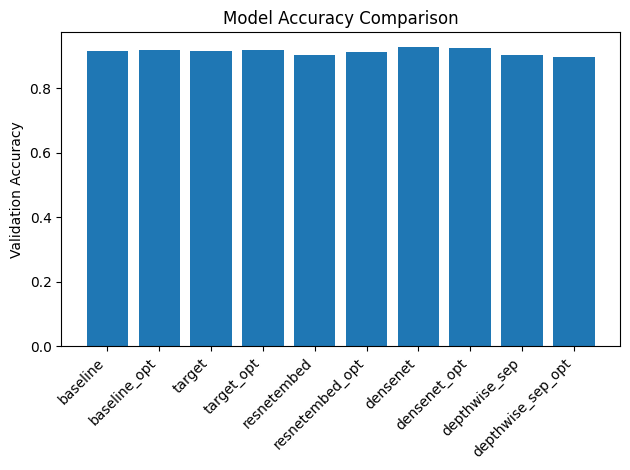

In [78]:
# 3) Bar‐chart: Validation Accuracy
plt.figure()
plt.bar(metrics_all['model'], metrics_all['accuracy'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Validation Accuracy')
plt.title('Model Accuracy Comparison')
plt.tight_layout()
plt.show()


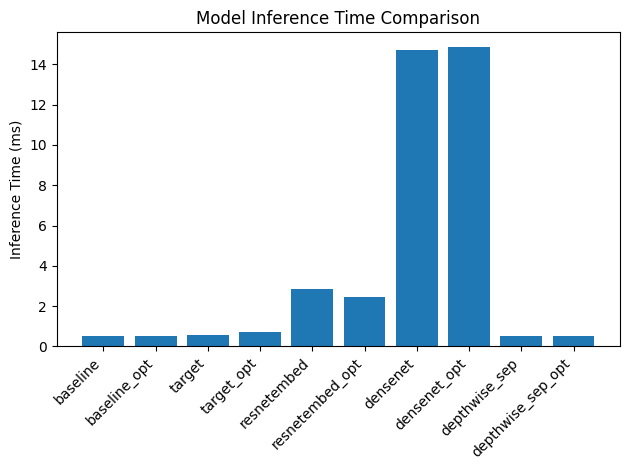

In [79]:
# 4) Bar‐chart: Inference Time
plt.figure()
plt.bar(metrics_all['model'], metrics_all['inference_time_ms'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Inference Time (ms)')
plt.title('Model Inference Time Comparison')
plt.tight_layout()
plt.show()


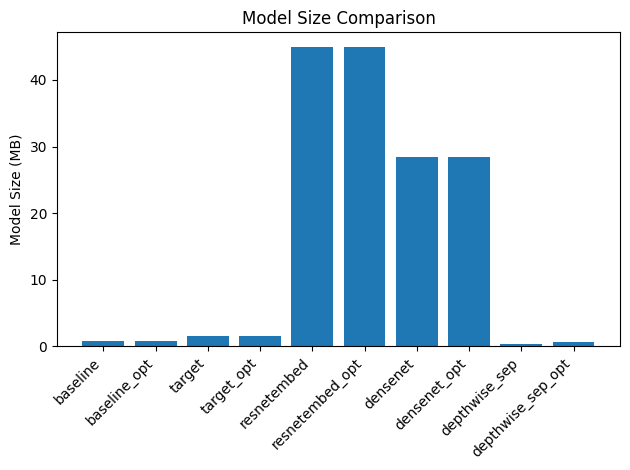

In [80]:
# 5) Bar‐chart: Model Size
plt.figure()
plt.bar(metrics_all['model'], metrics_all['model_size_mb'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Model Size (MB)')
plt.title('Model Size Comparison')
plt.tight_layout()
plt.show()


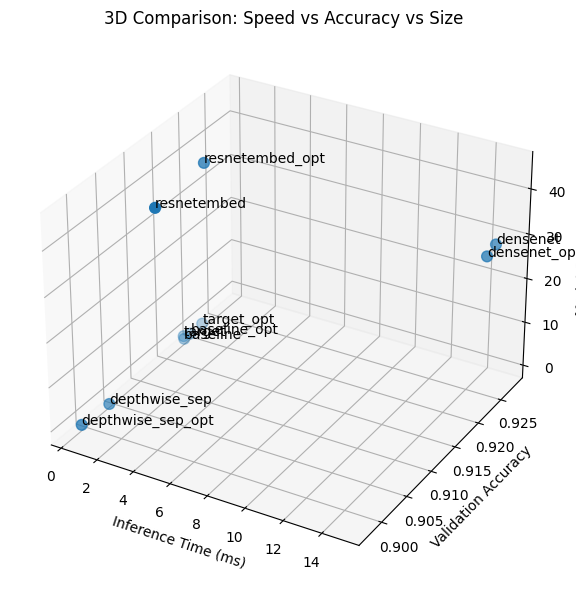

In [81]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 3D scatter: Speed vs Accuracy vs Size
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    metrics_all['inference_time_ms'],
    metrics_all['accuracy'],
    metrics_all['model_size_mb'],
    s=60
)

# Annotate each point with the model name
for _, row in metrics_all.iterrows():
    ax.text(
        row['inference_time_ms'],
        row['accuracy'],
        row['model_size_mb'],
        row['model']
    )

ax.set_xlabel('Inference Time (ms)')
ax.set_ylabel('Validation Accuracy')
ax.set_zlabel('Model Size (MB)')
ax.set_title('3D Comparison: Speed vs Accuracy vs Size')
plt.tight_layout()
plt.show()


In [82]:
# 1) Compile final metrics into a DataFrame
import pandas as pd

metrics_all = pd.DataFrame([
    {'model':'baseline',           'accuracy': history['val_acc'][-1],        'inference_time_ms': inf_ms,        'model_size_mb': size_mb},
    {'model':'baseline_opt',       'accuracy': history_opt['val_acc'][-1],    'inference_time_ms': inf_ms,        'model_size_mb': size_mb},
    {'model':'target',             'accuracy': history_t['val_acc'][-1],      'inference_time_ms': inf_t,         'model_size_mb': size_t},
    {'model':'target_opt',         'accuracy': history_opt_t['val_acc'][-1],  'inference_time_ms': inf_opt_t,     'model_size_mb': size_opt_t},
    {'model':'resnetembed',        'accuracy': history_e['val_acc'][-1],      'inference_time_ms': inf_e,         'model_size_mb': size_e},
    {'model':'resnetembed_opt',    'accuracy': history_opt_e['val_acc'][-1],  'inference_time_ms': inf_opt_e,     'model_size_mb': size_opt_e},
    {'model':'densenet',           'accuracy': history_d['val_acc'][-1],      'inference_time_ms': inf_d,         'model_size_mb': size_d},
    {'model':'densenet_opt',       'accuracy': history_opt_d['val_acc'][-1],  'inference_time_ms': inf_opt_d,     'model_size_mb': size_opt_d},
    {'model':'depthwise_sep',      'accuracy': history_ds['val_acc'][-1],     'inference_time_ms': inf_ds,        'model_size_mb': size_ds},
    {'model':'depthwise_sep_opt',  'accuracy': history_opt_ds['val_acc'][-1], 'inference_time_ms': inf_opt_ds,    'model_size_mb': size_opt_ds},
])

# 2) Print the table of values
print(metrics_all)


               model  accuracy  inference_time_ms  model_size_mb
0           baseline    0.9166           0.540941       0.830416
1       baseline_opt    0.9178           0.540941       0.830416
2             target    0.9165           0.542016       1.564800
3         target_opt    0.9196           0.696063       1.564800
4        resnetembed    0.9044           2.840543      44.888954
5    resnetembed_opt    0.9146           2.445040      44.888954
6           densenet    0.9277          14.694633      28.394264
7       densenet_opt    0.9251          14.850721      28.394264
8      depthwise_sep    0.9026           0.531163       0.290560
9  depthwise_sep_opt    0.8978           0.494840       0.643328


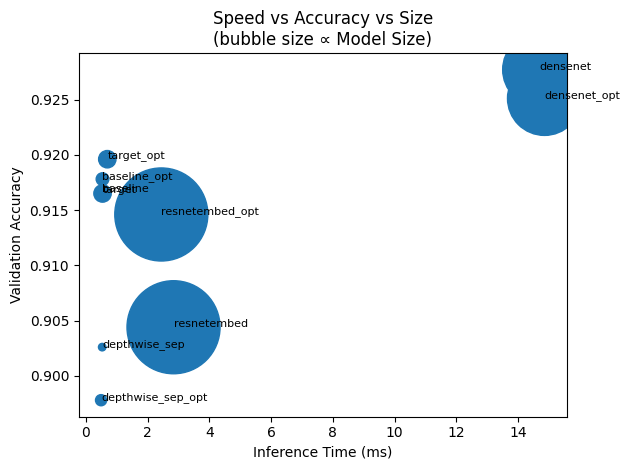

In [83]:
# 3) Bubble chart: Inference Time vs. Accuracy vs. Model Size
import matplotlib.pyplot as plt

plt.figure()
# scale bubble area by model size for visibility
bubble_sizes = metrics_all['model_size_mb'] * 100
plt.scatter(
    metrics_all['inference_time_ms'],
    metrics_all['accuracy'],
    s=bubble_sizes
)
for _, row in metrics_all.iterrows():
    plt.text(row['inference_time_ms'], row['accuracy'], row['model'], fontsize=8)
plt.xlabel('Inference Time (ms)')
plt.ylabel('Validation Accuracy')
plt.title('Speed vs Accuracy vs Size\n(bubble size ∝ Model Size)')
plt.tight_layout()
plt.show()


In [84]:
# 1) Create a directory to hold all results
import os
os.makedirs('results', exist_ok=True)


In [85]:
# 2) Save the final metrics comparison
metrics_all.to_csv('results/metrics_all.csv', index=False)
print("Saved: results/metrics_all.csv")


Saved: results/metrics_all.csv


In [86]:
# 3) Save hyperparameter search results for each model
df.to_csv('results/hp_baseline.csv', index=False)
df_t.to_csv('results/hp_target.csv', index=False)
df_e.to_csv('results/hp_resnetembed.csv', index=False)
df_d.to_csv('results/hp_densenet.csv', index=False)
df_ds.to_csv('results/hp_depthwise_sep.csv', index=False)
print("Saved hyperparameter search results for all models.")


Saved hyperparameter search results for all models.


In [87]:
# 4) Save training histories (loss/accuracy/F1 per epoch)
import pandas as pd

pd.DataFrame(history).to_csv('results/history_baseline.csv', index=False)
pd.DataFrame(history_opt).to_csv('results/history_baseline_opt.csv', index=False)
pd.DataFrame(history_t).to_csv('results/history_target.csv', index=False)
pd.DataFrame(history_opt_t).to_csv('results/history_target_opt.csv', index=False)
pd.DataFrame(history_e).to_csv('results/history_resnetembed.csv', index=False)
pd.DataFrame(history_opt_e).to_csv('results/history_resnetembed_opt.csv', index=False)
pd.DataFrame(history_d).to_csv('results/history_densenet.csv', index=False)
pd.DataFrame(history_opt_d).to_csv('results/history_densenet_opt.csv', index=False)
pd.DataFrame(history_ds).to_csv('results/history_depthwise_sep.csv', index=False)
pd.DataFrame(history_opt_ds).to_csv('results/history_depthwise_sep_opt.csv', index=False)

print("Saved training histories for all models.")


Saved training histories for all models.
